In [ ]:
!pip install -q optbinning openpyxl joblib statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 24.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


# Import lib

In [ ]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optbinning import OptimalBinning

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

cleaned_dataset = pd.read_csv('/content/drive/MyDrive/AIO 2026/Conquer/Data/cleaned_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CẤU HÌNH CHUNG
# ============================================================

TARGET = "loan_status"

CATEGORICAL_FEATURES = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# IV tối thiểu để đưa vào feature selection
IV_THRESHOLD = 0.02

# Cảnh báo chất lượng bin
SMALL_BIN_THRESHOLD = 0.05
EXTREME_WOE_THRESHOLD = 2.0

# Cấu hình Optimal Binning
BINNING_CONFIG = {
    "prebinning_method": "cart",
    "solver": "cp",
    "divergence": "iv",
    "max_n_prebins": 20,
    "min_prebin_size": 0.05,
    "max_n_bins": 6,
    "monotonic_trend": "auto"
}

# ------------------------------------------------------------
# Bối cảnh sử dụng mô hình
# ------------------------------------------------------------
#
# "all_available":
#     Giữ tất cả biến đã có trong dataset.
#
# "pre_decision":
#     Loại loan_grade và loan_int_rate vì hai biến này có thể
#     chỉ xuất hiện sau quá trình đánh giá/định giá khoản vay.
#
MODEL_CONTEXT = "all_available"

if MODEL_CONTEXT == "pre_decision":
    BUSINESS_EXCLUDE = [
        "loan_grade",
        "loan_int_rate"
    ]
else:
    BUSINESS_EXCLUDE = []

# ------------------------------------------------------------
# Đường dẫn lưu output
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "AIO 2026/Conquer/Data/"
    "train_test_feature_selection"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection


In [ ]:
def validate_cleaned_dataset(
    data,
    target,
    categorical_features
):
    """
    Kiểm tra cấu trúc dữ liệu trước khi chia train/test.
    """

    if not isinstance(data, pd.DataFrame):
        raise TypeError(
            "cleaned_dataset phải là pandas DataFrame."
        )

    if data.empty:
        raise ValueError(
            "cleaned_dataset không có quan sát."
        )

    if data.columns.duplicated().any():
        duplicated_columns = (
            data.columns[
                data.columns.duplicated()
            ]
            .tolist()
        )

        raise ValueError(
            f"Có tên cột bị trùng: {duplicated_columns}"
        )

    if target not in data.columns:
        raise KeyError(
            f"Không tìm thấy target '{target}'."
        )

    if data[target].isna().any():
        raise ValueError(
            f"Target '{target}' chứa missing values."
        )

    target_values = set(
        data[target]
        .unique()
        .tolist()
    )

    if target_values != {0, 1}:
        raise ValueError(
            f"{target} phải nhận đúng {{0, 1}}. "
            f"Hiện tại: {target_values}"
        )

    missing_categorical = [
        feature
        for feature in categorical_features
        if feature not in data.columns
    ]

    if missing_categorical:
        raise KeyError(
            "Không tìm thấy các biến categorical: "
            f"{missing_categorical}"
        )

    features = [
        column
        for column in data.columns
        if column != target
    ]

    numerical_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]

    print("=" * 70)
    print("KIỂM TRA CLEANED DATASET")
    print("=" * 70)

    print(f"Số quan sát: {len(data):,}")
    print(f"Số biến dự báo: {len(features)}")
    print(
        f"Tỷ lệ default: "
        f"{data[target].mean():.2%}"
    )

    print("\nNumerical features:")
    print(numerical_features)

    print("\nCategorical features:")
    print(categorical_features)

    return (
        features,
        numerical_features
    )

# New Section

In [ ]:
FEATURES, NUMERICAL_FEATURES = (
    validate_cleaned_dataset(
        data=cleaned_dataset,
        target=TARGET,
        categorical_features=(
            CATEGORICAL_FEATURES
        )
    )
)

KIỂM TRA CLEANED DATASET
Số quan sát: 31,679
Số biến dự báo: 11
Tỷ lệ default: 21.54%

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## Train/Test Split

In [ ]:
train_data, test_data = train_test_split(
    cleaned_dataset,
    test_size=TEST_SIZE,
    stratify=cleaned_dataset[TARGET],
    random_state=RANDOM_STATE,
    shuffle=True
)

train_data = train_data.copy()
test_data = test_data.copy()

# Kiểm tra hai tập không trùng nhau
overlap = train_data.index.intersection(
    test_data.index
)

assert len(overlap) == 0, (
    "Train và test có index bị trùng."
)

assert (
    len(train_data) + len(test_data)
    == len(cleaned_dataset)
), "Tổng số quan sát không khớp."

print("=" * 70)
print("TRAIN/TEST SPLIT")
print("=" * 70)

print(
    f"Train: {train_data.shape}, "
    f"default rate = "
    f"{train_data[TARGET].mean():.2%}"
)

print(
    f"Test:  {test_data.shape}, "
    f"default rate = "
    f"{test_data[TARGET].mean():.2%}"
)

TRAIN/TEST SPLIT
Train: (25343, 12), default rate = 21.54%
Test:  (6336, 12), default rate = 21.54%


In [ ]:
train_data.to_csv(
    OUTPUT_DIR / "train_cleaned_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_data.to_csv(
    OUTPUT_DIR / "test_cleaned_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

## Binning

In [ ]:
def clean_binning_table(table):
    """
    Loại Totals/Total và các dòng Count = 0.
    """

    result = table.copy()

    index_labels = (
        result.index
        .astype(str)
        .str.strip()
    )

    result = result.loc[
        ~index_labels.isin(
            ["Totals", "Total"]
        )
    ].copy()

    result = result.reset_index(
        drop=True
    )

    if "Count" in result.columns:
        result = (
            result.loc[
                result["Count"] > 0
            ]
            .reset_index(drop=True)
        )

    return result

In [ ]:
def prepare_feature_array(
    data,
    feature,
    categorical_features
):
    """
    Chuẩn bị một biến trước khi đưa vào OptBinning.
    """

    if feature in categorical_features:
        return (
            data[feature]
            .astype(object)
            .to_numpy()
        )

    return pd.to_numeric(
        data[feature],
        errors="coerce"
    ).to_numpy()

In [ ]:
def fit_optimal_binning_train(
    train_data,
    features,
    categorical_features,
    target,
    config
):
    """
    Fit một OptimalBinning model cho từng biến,
    chỉ sử dụng tập train.
    """

    y_train = (
        train_data[target]
        .astype(int)
        .to_numpy()
    )

    categorical_set = set(
        categorical_features
    )

    models = {}
    full_tables = {}
    cleaned_tables = {}
    summary_rows = []

    print("=" * 90)
    print("FIT OPTIMAL BINNING TRÊN TRAIN")
    print("=" * 90)

    for feature in features:

        feature_type = (
            "categorical"
            if feature in categorical_set
            else "numerical"
        )

        parameters = {
            "name": feature,
            "dtype": feature_type,
            "prebinning_method": (
                config["prebinning_method"]
            ),
            "solver": config["solver"],
            "divergence": config["divergence"],
            "max_n_prebins": (
                config["max_n_prebins"]
            ),
            "min_prebin_size": (
                config["min_prebin_size"]
            ),
            "max_n_bins": (
                config["max_n_bins"]
            )
        }

        if feature_type == "numerical":
            parameters["monotonic_trend"] = (
                config["monotonic_trend"]
            )

        model = OptimalBinning(
            **parameters
        )

        x_train = prepare_feature_array(
            data=train_data,
            feature=feature,
            categorical_features=(
                categorical_set
            )
        )

        try:
            model.fit(
                x_train,
                y_train
            )

        except Exception as error:
            raise RuntimeError(
                f"Lỗi khi fit biến '{feature}': "
                f"{error}"
            ) from error

        full_table = (
            model.binning_table
            .build()
        )

        cleaned_table = clean_binning_table(
            full_table
        )

        status = getattr(
            model,
            "status",
            "UNKNOWN"
        )

        iv_value = float(
            model.binning_table.iv
        )

        models[feature] = model
        full_tables[feature] = full_table
        cleaned_tables[feature] = (
            cleaned_table
        )

        summary_rows.append({
            "Variable": feature,
            "Type": feature_type,
            "Status": status,
            "Number of bins": len(
                cleaned_table
            ),
            "IV": iv_value
        })

        print(
            f"{feature:<35}"
            f"type={feature_type:<12}"
            f"status={status:<10}"
            f"bins={len(cleaned_table):<3}"
            f"IV={iv_value:.6f}"
        )

    iv_summary = (
        pd.DataFrame(summary_rows)
        .sort_values(
            "IV",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        "models": models,
        "full_tables": full_tables,
        "cleaned_tables": cleaned_tables,
        "iv_summary": iv_summary
    }

In [ ]:
binning_fit = fit_optimal_binning_train(
    train_data=train_data,
    features=FEATURES,
    categorical_features=(
        CATEGORICAL_FEATURES
    ),
    target=TARGET,
    config=BINNING_CONFIG
)

FIT OPTIMAL BINNING TRÊN TRAIN
person_age                         type=numerical   status=OPTIMAL   bins=6  IV=0.010366
person_income                      type=numerical   status=OPTIMAL   bins=6  IV=0.507781
person_home_ownership              type=categorical status=OPTIMAL   bins=3  IV=0.374315
person_emp_length                  type=numerical   status=OPTIMAL   bins=6  IV=0.063267
loan_intent                        type=categorical status=OPTIMAL   bins=6  IV=0.104165
loan_grade                         type=categorical status=OPTIMAL   bins=4  IV=0.865536
loan_amnt                          type=numerical   status=OPTIMAL   bins=6  IV=0.096976
loan_int_rate                      type=numerical   status=OPTIMAL   bins=7  IV=0.687478
loan_percent_income                type=numerical   status=OPTIMAL   bins=6  IV=0.952602
cb_person_default_on_file          type=categorical status=OPTIMAL   bins=2  IV=0.166233
cb_person_cred_hist_length         type=numerical   status=OPTIMAL   bins=6  IV

In [ ]:
binning_models = binning_fit[
    "models"
]

binning_tables = binning_fit[
    "full_tables"
]

cleaned_binning_tables = binning_fit[
    "cleaned_tables"
]

iv_summary_train = binning_fit[
    "iv_summary"
]

display(
    iv_summary_train.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,Type,Status,Number of bins,IV
0,loan_percent_income,numerical,OPTIMAL,6,0.952602
1,loan_grade,categorical,OPTIMAL,4,0.865536
2,loan_int_rate,numerical,OPTIMAL,7,0.687478
3,person_income,numerical,OPTIMAL,6,0.507781
4,person_home_ownership,categorical,OPTIMAL,3,0.374315
5,cb_person_default_on_file,categorical,OPTIMAL,2,0.166233
6,loan_intent,categorical,OPTIMAL,6,0.104165
7,loan_amnt,numerical,OPTIMAL,6,0.096976
8,person_emp_length,numerical,OPTIMAL,6,0.063267
9,person_age,numerical,OPTIMAL,6,0.010366


# WOE

In [ ]:
def transform_with_binning_models(
    data,
    models,
    features,
    categorical_features,
    target=None,
    show_digits=4
):
    """
    Chỉ transform. Không fit lại mô hình.
    """

    categorical_set = set(
        categorical_features
    )

    bin_data = pd.DataFrame(
        index=data.index
    )

    woe_data = pd.DataFrame(
        index=data.index
    )

    for feature in features:

        if feature not in data.columns:
            raise KeyError(
                f"Thiếu biến '{feature}'."
            )

        x = prepare_feature_array(
            data=data,
            feature=feature,
            categorical_features=(
                categorical_set
            )
        )

        model = models[feature]

        bin_data[feature] = (
            model.transform(
                x,
                metric="bins",
                show_digits=show_digits
            )
        )

        woe_data[feature] = (
            model.transform(
                x,
                metric="woe",
                metric_missing="empirical",
                metric_special="empirical"
            )
        )

    if target is not None:
        bin_data[target] = (
            data[target]
            .astype(int)
        )

        woe_data[target] = (
            data[target]
            .astype(int)
        )

    return bin_data, woe_data

In [ ]:
train_bin_dataset, train_woe_dataset = (
    transform_with_binning_models(
        data=train_data,
        models=binning_models,
        features=FEATURES,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        target=TARGET
    )
)

In [ ]:
test_bin_dataset, test_woe_dataset = (
    transform_with_binning_models(
        data=test_data,
        models=binning_models,
        features=FEATURES,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        target=TARGET
    )
)

## Validate WOE

In [ ]:
def validate_woe_dataset(
    woe_data,
    original_data,
    features,
    target,
    dataset_name
):
    """
    Kiểm tra tính toàn vẹn sau WOE transformation.
    """

    if not woe_data.index.equals(
        original_data.index
    ):
        raise ValueError(
            f"{dataset_name}: index bị thay đổi."
        )

    if not woe_data[target].equals(
        original_data[target].astype(int)
    ):
        raise ValueError(
            f"{dataset_name}: target bị thay đổi."
        )

    missing_count = int(
        woe_data[features]
        .isna()
        .sum()
        .sum()
    )

    infinite_count = int(
        np.isinf(
            woe_data[features]
            .to_numpy(dtype=float)
        )
        .sum()
    )

    constant_features = [
        feature
        for feature in features
        if (
            woe_data[feature]
            .nunique(dropna=False)
            <= 1
        )
    ]

    print("=" * 65)
    print(dataset_name)
    print("=" * 65)

    print(
        f"Số quan sát: {len(woe_data):,}"
    )

    print(
        f"Missing WOE: {missing_count}"
    )

    print(
        f"Infinite WOE: {infinite_count}"
    )

    print(
        "Biến hằng:",
        constant_features
        if constant_features
        else "Không có"
    )

    if missing_count > 0:
        raise ValueError(
            f"{dataset_name} còn missing WOE."
        )

    if infinite_count > 0:
        raise ValueError(
            f"{dataset_name} có infinite WOE."
        )

    return constant_features

In [ ]:
constant_train_features = (
    validate_woe_dataset(
        woe_data=train_woe_dataset,
        original_data=train_data,
        features=FEATURES,
        target=TARGET,
        dataset_name="TRAIN WOE"
    )
)

constant_test_features = (
    validate_woe_dataset(
        woe_data=test_woe_dataset,
        original_data=test_data,
        features=FEATURES,
        target=TARGET,
        dataset_name="TEST WOE"
    )
)

TRAIN WOE
Số quan sát: 25,343
Missing WOE: 0
Infinite WOE: 0
Biến hằng: Không có
TEST WOE
Số quan sát: 6,336
Missing WOE: 0
Infinite WOE: 0
Biến hằng: Không có


In [ ]:
def check_unseen_categories(
    train_data,
    test_data,
    categorical_features
):
    rows = []

    for feature in categorical_features:

        train_categories = set(
            train_data[feature]
            .dropna()
            .astype(str)
            .unique()
        )

        test_categories = set(
            test_data[feature]
            .dropna()
            .astype(str)
            .unique()
        )

        unseen = sorted(
            test_categories
            - train_categories
        )

        rows.append({
            "Variable": feature,
            "Train category count": len(
                train_categories
            ),
            "Test category count": len(
                test_categories
            ),
            "Unseen categories": unseen,
            "Has unseen category": (
                len(unseen) > 0
            )
        })

    return pd.DataFrame(rows)

In [ ]:
unseen_category_check = (
    check_unseen_categories(
        train_data=train_data,
        test_data=test_data,
        categorical_features=(
            CATEGORICAL_FEATURES
        )
    )
)

display(
    unseen_category_check
)

,Variable,Train category count,Test category count,Unseen categories,Has unseen category
0,person_home_ownership,4,4,[],False
1,loan_intent,6,6,[],False
2,loan_grade,7,7,[],False
3,cb_person_default_on_file,2,2,[],False


In [ ]:
def check_bin_woe_mapping(
    bin_data,
    woe_data,
    features,
    dataset_name
):
    rows = []

    for feature in features:

        temporary = pd.DataFrame({
            "Bin": (
                bin_data[feature]
                .reset_index(drop=True)
            ),
            "WOE": (
                woe_data[feature]
                .reset_index(drop=True)
            )
        })

        woe_per_bin = (
            temporary
            .groupby(
                "Bin",
                dropna=False
            )["WOE"]
            .nunique()
        )

        max_woe_per_bin = int(
            woe_per_bin.max()
        )

        rows.append({
            "Dataset": dataset_name,
            "Variable": feature,
            "Number of bins": (
                temporary["Bin"]
                .nunique(dropna=False)
            ),
            "Number of WOE values": (
                temporary["WOE"]
                .nunique(dropna=False)
            ),
            "Maximum WOE per bin": (
                max_woe_per_bin
            ),
            "Mapping is valid": (
                max_woe_per_bin == 1
            )
        })

    return pd.DataFrame(rows)

In [ ]:
train_mapping_check = (
    check_bin_woe_mapping(
        bin_data=train_bin_dataset,
        woe_data=train_woe_dataset,
        features=FEATURES,
        dataset_name="Train"
    )
)

test_mapping_check = (
    check_bin_woe_mapping(
        bin_data=test_bin_dataset,
        woe_data=test_woe_dataset,
        features=FEATURES,
        dataset_name="Test"
    )
)

mapping_check = pd.concat(
    [
        train_mapping_check,
        test_mapping_check
    ],
    ignore_index=True
)

display(mapping_check)

assert mapping_check[
    "Mapping is valid"
].all(), (
    "Có mapping bin–WOE không hợp lệ."
)

,Dataset,Variable,Number of bins,Number of WOE values,Maximum WOE per bin,Mapping is valid
0,Train,person_age,6,6,1,True
1,Train,person_income,6,6,1,True
2,Train,person_home_ownership,3,3,1,True
3,Train,person_emp_length,6,6,1,True
4,Train,loan_intent,6,6,1,True
5,Train,loan_grade,4,4,1,True
6,Train,loan_amnt,6,6,1,True
7,Train,loan_int_rate,7,7,1,True
8,Train,loan_percent_income,6,6,1,True
9,Train,cb_person_default_on_file,2,2,1,True


In [ ]:
def create_binning_diagnostics(
    cleaned_tables,
    n_train,
    small_bin_threshold=0.05,
    extreme_woe_threshold=2.0
):
    rows = []

    for feature, table in (
        cleaned_tables.items()
    ):

        for _, row in table.iterrows():

            count = int(row["Count"])
            good = int(row["Non-event"])
            bad = int(row["Event"])

            share = count / n_train
            woe = float(row["WoE"])

            rows.append({
                "Variable": feature,
                "Bin": row["Bin"],
                "Count": count,
                "Share": share,
                "Number of good": good,
                "Number of bad": bad,
                "Default rate": float(
                    row["Event rate"]
                ),
                "WOE": woe,
                "Bin IV": float(
                    row["IV"]
                ),
                "Small bin": (
                    share
                    < small_bin_threshold
                ),
                "Extreme WOE": (
                    abs(woe)
                    > extreme_woe_threshold
                ),
                "Pure bin": (
                    good == 0 or bad == 0
                )
            })

    diagnostic_table = pd.DataFrame(
        rows
    )

    warning_table = (
        diagnostic_table.loc[
            diagnostic_table[
                [
                    "Small bin",
                    "Extreme WOE",
                    "Pure bin"
                ]
            ].any(axis=1)
        ]
        .sort_values(
            [
                "Extreme WOE",
                "Pure bin",
                "Small bin",
                "Share"
            ],
            ascending=[
                False,
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    return (
        diagnostic_table,
        warning_table
    )

In [ ]:
train_diagnostic_table, train_warning_table = (
    create_binning_diagnostics(
        cleaned_tables=(
            cleaned_binning_tables
        ),
        n_train=len(train_data),
        small_bin_threshold=(
            SMALL_BIN_THRESHOLD
        ),
        extreme_woe_threshold=(
            EXTREME_WOE_THRESHOLD
        )
    )
)

print(
    "Số bin cần rà soát:",
    len(train_warning_table)
)

display(
    train_warning_table.style.format({
        "Share": "{:.2%}",
        "Default rate": "{:.2%}",
        "WOE": "{:.4f}",
        "Bin IV": "{:.4f}"
    })
)

Số bin cần rà soát: 2


,Variable,Bin,Count,Share,Number of good,Number of bad,Default rate,WOE,Bin IV,Small bin,Extreme WOE,Pure bin
0,loan_percent_income,"[0.38, inf)",1315,5.19%,350,965,73.38%,-2.3066,0.3671,False,True,False
1,loan_percent_income,"[0.31, 0.38)",1623,6.40%,516,1107,68.21%,-2.0557,0.3634,False,True,False


## IV sreening

In [ ]:
def create_feature_screening_table(
    iv_summary,
    train_woe_data,
    iv_threshold,
    business_exclude
):
    table = iv_summary.copy()

    table["Constant WOE"] = (
        table["Variable"]
        .map(
            lambda feature:
            train_woe_data[feature]
            .nunique(dropna=False)
            <= 1
        )
    )

    table["Pass IV"] = (
        table["IV"]
        >= iv_threshold
    )

    table["Business excluded"] = (
        table["Variable"]
        .isin(business_exclude)
    )

    table["Candidate for LASSO"] = (
        table["Pass IV"]
        & ~table["Constant WOE"]
        & ~table["Business excluded"]
    )

    def determine_reason(row):

        if row["Constant WOE"]:
            return "Loại: WOE không có biến thiên"

        if not row["Pass IV"]:
            return (
                f"Loại: IV < {iv_threshold}"
            )

        if row["Business excluded"]:
            return (
                "Loại: không phù hợp "
                "prediction timestamp"
            )

        return "Giữ: đưa vào LASSO"

    table["Decision"] = table.apply(
        determine_reason,
        axis=1
    )

    return table

In [ ]:
feature_screening_table = (
    create_feature_screening_table(
        iv_summary=iv_summary_train,
        train_woe_data=(
            train_woe_dataset
        ),
        iv_threshold=IV_THRESHOLD,
        business_exclude=(
            BUSINESS_EXCLUDE
        )
    )
)

display(
    feature_screening_table.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,Type,Status,Number of bins,IV,Constant WOE,Pass IV,Business excluded,Candidate for LASSO,Decision
0,loan_percent_income,numerical,OPTIMAL,6,0.952602,False,True,False,True,Giữ: đưa vào LASSO
1,loan_grade,categorical,OPTIMAL,4,0.865536,False,True,False,True,Giữ: đưa vào LASSO
2,loan_int_rate,numerical,OPTIMAL,7,0.687478,False,True,False,True,Giữ: đưa vào LASSO
3,person_income,numerical,OPTIMAL,6,0.507781,False,True,False,True,Giữ: đưa vào LASSO
4,person_home_ownership,categorical,OPTIMAL,3,0.374315,False,True,False,True,Giữ: đưa vào LASSO
5,cb_person_default_on_file,categorical,OPTIMAL,2,0.166233,False,True,False,True,Giữ: đưa vào LASSO
6,loan_intent,categorical,OPTIMAL,6,0.104165,False,True,False,True,Giữ: đưa vào LASSO
7,loan_amnt,numerical,OPTIMAL,6,0.096976,False,True,False,True,Giữ: đưa vào LASSO
8,person_emp_length,numerical,OPTIMAL,6,0.063267,False,True,False,True,Giữ: đưa vào LASSO
9,person_age,numerical,OPTIMAL,6,0.010366,False,False,False,False,Loại: IV < 0.02


In [ ]:
candidate_features = (
    feature_screening_table.loc[
        feature_screening_table[
            "Candidate for LASSO"
        ],
        "Variable"
    ]
    .tolist()
)

print("Các biến ứng viên cho LASSO:")
print(candidate_features)

print(
    "Số biến ứng viên:",
    len(candidate_features)
)

Các biến ứng viên cho LASSO:
['loan_percent_income', 'loan_grade', 'loan_int_rate', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt', 'person_emp_length']
Số biến ứng viên: 9


## Preparation for FS

In [ ]:
X_train_selection = (
    train_woe_dataset[
        candidate_features
    ]
    .astype(float)
    .copy()
)

y_train_selection = (
    train_woe_dataset[TARGET]
    .astype(int)
    .copy()
)

# Test chỉ được chuẩn bị để dùng sau này.
# Không đưa test vào LASSO CV.
X_test_reserved = (
    test_woe_dataset[
        candidate_features
    ]
    .astype(float)
    .copy()
)

y_test_reserved = (
    test_woe_dataset[TARGET]
    .astype(int)
    .copy()
)

print(
    "X_train_selection:",
    X_train_selection.shape
)

print(
    "X_test_reserved:",
    X_test_reserved.shape
)

X_train_selection: (25343, 9)
X_test_reserved: (6336, 9)


# Feature Selection cho mô hình Credit Scoring

## Mục tiêu

Sau khi hoàn thành Optimal Binning và chuyển đổi dữ liệu sang Weight of Evidence (WOE), bước tiếp theo là lựa chọn tập biến phù hợp cho mô hình hồi quy logistic.

Quy trình feature selection nhằm:

- Loại bỏ các biến có khả năng phân biệt quá thấp.
- Hạn chế đa cộng tuyến giữa các biến dự báo.
- Xác định tập biến có khả năng dự báo tốt.
- Kiểm tra độ ổn định của lựa chọn biến bằng nhiều phương pháp.
- Rà soát các biến không tồn tại bước chấm điểm.
- Chuẩn bị các tập biến ứng viên cho bước xây dựng mô hình.

Notebook này chỉ thực hiện **feature selection**.

Notebook chưa:

- fit mô hình logistic cuối cùng;
- đánh giá AUC/Gini trên tập test;
- lựa chọn classification threshold;
- xây dựng scorecard.

## Dữ liệu đầu vào

Feature selection sử dụng ba tệp được tạo từ bước Optimal Binning:

```text
train_woe_dataset.csv
test_woe_dataset.csv
iv_summary_train.csv
```

Trong đó:

- `train_woe_dataset.csv`: dữ liệu train sau khi chuyển đổi WOE.
- `test_woe_dataset.csv`: dữ liệu test được chuyển đổi bằng đúng các binning model đã fit trên train.
- `iv_summary_train.csv`: bảng Information Value được tính hoàn toàn từ tập train.


Tập test chỉ được giữ lại để đánh giá mô hình cuối cùng.

Tập test không được sử dụng để:

- tính IV;
- lựa chọn biến;
- lựa chọn giá trị $\lambda$;
- lựa chọn tổ hợp biến;
- điều chỉnh ngưỡng VIF;
- lựa chọn giữa các mô hình ứng viên.

## Luồng Feature Selection

```text
train_woe_dataset
        │
        ▼
IV screening
        │
        ▼
Rà soát prediction timestamp và leakage
        │
        ├── Full WOE candidates
        └── Pre-decision candidates
        │
        ▼
Kiểm tra đa cộng tuyến bằng VIF
        │
        ▼
LASSO cross-validation
        │
        ├── lambda.min
        └── lambda.1se
        │
Best-subset selection
        │
        ├── VIF constraint
        ├── OOF AUC/Gini
        ├── Brier score
        └── Quy tắc 1-SE
        │
        ▼
Pre-decision best-subset
        │
        ▼
Tập biến ứng viên

```

## Kết quả IV Screening

Theo kết quả được tính trên tập train, hai biến có IV rất thấp là:

```text
person_age
cb_person_cred_hist_length
```

Hai biến này có:

$$
IV<0.02
$$

nên được loại khỏi tập ứng viên chính.

Sau IV screening còn lại chín biến:

```text
loan_percent_income
loan_grade
loan_int_rate
person_income
person_home_ownership
cb_person_default_on_file
loan_intent
loan_amnt
person_emp_length
```

Các biến này tiếp tục được đưa vào:

- rà soát nghiệp vụ;
- kiểm tra đa cộng tuyến;
- LASSO cross-validation;
- best-subset selection.



# Rà soát nghiệp vụ và nguy cơ Leakage

## Prediction timestamp


Quy trình tín dụng có thể được biểu diễn:

```text
Khách hàng nộp hồ sơ
        │
        ▼
Thu thập thông tin
        │
        ▼
Chấm điểm rủi ro
        │
        ▼
Xếp hạng khoản vay
        │
        ▼
Xác định lãi suất
        │
        ▼
Ra quyết định tín dụng
```

Hai biến cần đặc biệt rà soát:

```text
loan_grade
loan_int_rate
```

`loan_grade` có thể là kết quả của một hệ thống đánh giá tín dụng đã tồn tại.

`loan_int_rate` có thể được quyết định sau khi tổ chức tín dụng đã đánh giá mức độ rủi ro của khách hàng.

Nếu mô hình được sử dụng trước khi grade và lãi suất được xác định, sử dụng hai biến này có thể tạo ra leakage.

## Các tập biến ứng viên

### Full WOE candidates

Tập Full WOE giữ tất cả biến vượt qua IV screening:

```text
loan_percent_income
loan_grade
loan_int_rate
person_income
person_home_ownership
cb_person_default_on_file
loan_intent
loan_amnt
person_emp_length
```

Tập này được sử dụng để:

- tạo benchmark;
- đánh giá mức hiệu năng khi sử dụng toàn bộ thông tin;
- kiểm tra đa cộng tuyến;
- so sánh với các mô hình gọn hơn.

### Pre-decision candidates

Tập pre-decision loại:

```text
loan_grade
loan_int_rate
```

Các biến còn lại:

```text
loan_percent_income
person_income
person_home_ownership
cb_person_default_on_file
loan_intent
loan_amnt
person_emp_length
```

Nhánh pre-decision trả lời câu hỏi:

> Khả năng phân biệt còn bao nhiêu khi chỉ sử dụng thông tin có sẵn trước quyết định tín dụng?

## Các nhóm biến có thể chồng lặp thông tin

Ba biến:

```text
loan_percent_income
loan_amnt
person_income
```

có quan hệ:

$$
loan\_percent\_income
\approx
\frac{loan\_amnt}{person\_income}.
$$



Các tổ hợp cần được so sánh:

```text
Mô hình A:
loan_percent_income

Mô hình B:
loan_amnt + person_income

Mô hình C:
loan_percent_income + person_income

Mô hình D:
loan_percent_income + loan_amnt
```


# Kiểm tra đa cộng tuyến bằng VIF

Variance Inflation Factor của biến \(X_j\) được xác định bởi:

$$
VIF_j
=
\frac{1}{1-R_j^2},
$$

trong đó $R_j^2$ là hệ số xác định khi hồi quy $X_j$ theo các biến dự báo còn lại.

Ngưỡng rà soát:

$$
VIF_j>5.
$$



Một biến có thể có VIF cao trong mô hình đầy đủ nhưng có VIF chấp nhận được trong một tổ hợp nhỏ hơn.

Vì vậy, VIF được sử dụng như một ràng buộc ở cấp độ tổ hợp:

$$
\max VIF(\text{tổ hợp})\le5.
$$

Quy trình:

```text
Tạo tổ hợp biến
        │
        ▼
Tính VIF
        │
        ├── max VIF > 5 → loại tổ hợp
        └── max VIF ≤ 5 → tiếp tục cross-validation
```

VIF được tính trên dữ liệu WOE vì đây là các biến thực sự được đưa vào hồi quy logistic.

# LASSO Logistic Regression



Bài toán tối ưu có dạng:

$$
\min_{\beta_0,\boldsymbol{\beta}}
\left[
-\ell(\beta_0,\boldsymbol{\beta})
+
\lambda
\sum_{j=1}^{p}
|\beta_j|
\right].
$$

Trong đó:

- $\ell$ là log-likelihood của mô hình logistic;
- $\lambda$ là mức độ regularization;
- $\lambda$ càng lớn thì mức phạt càng mạnh;
- hệ số của một số biến có thể bị đưa về đúng 0;
- biến có hệ số bằng 0 được xem là không được lựa chọn.

Trong scikit-learn:

$$
C=\frac{1}{\lambda}.
$$

Do đó:

```text
C nhỏ
    → lambda lớn
    → regularization mạnh
    → ít biến được giữ

C lớn
    → lambda nhỏ
    → regularization yếu
    → nhiều biến được giữ
```

## Standardization và Cross-Validation

Các biến được chuẩn hóa theo:

$$
Z_j
=
\frac{X_j-\bar X_j}{s_j}.
$$

Standardization được đặt bên trong `Pipeline`.

Trong mỗi fold:

```text
Training fold
    ├── tính mean và standard deviation
    ├── transform training fold
    └── fit LASSO

Validation fold
    └── transform bằng tham số của training fold
```

Validation fold không được sử dụng để tính các tham số chuẩn hóa.

LASSO sử dụng:

```text
10-fold Stratified Cross-Validation
```

`StratifiedKFold` giúp giữ tỷ lệ Good và Bad gần tương đương giữa các folds.

Trong mỗi lần lặp:

```text
9 folds
    └── fit StandardScaler và LASSO

1 fold
    └── dự báo xác suất vỡ nợ
```

Tiêu chí lựa chọn $\lambda$ là AUC:

$$
AUC\uparrow.
$$

Gini tương ứng:

$$
Gini=2AUC-1.
$$

## `lambda.min` và `lambda.1se`

### `lambda.min`

`lambda.min` là mức $\lambda$ tạo ra AUC cross-validation trung bình cao nhất.

Tập biến tại `lambda.min` thường:

- giữ nhiều biến hơn;
- có regularization yếu hơn;
- ưu tiên hiệu năng dự báo;


### `lambda.1se`

`lambda.1se` là mức $\lambda$ lớn nhất có hiệu năng vẫn nằm trong phạm vi một sai số chuẩn so với kết quả tốt nhất.

Ngưỡng một sai số chuẩn:

$$
AUC_{\text{threshold}}
=
AUC_{\max}
-
SE(AUC_{\max}).
$$

Trong số các mức phạt thỏa mãn điều kiện trên, lựa chọn mức $\lambda$ lớn nhất.

`lambda.1se` thường tạo mô hình:

- ít biến hơn;
- dễ giải thích hơn;
- regularization mạnh hơn;
- phù hợp hơn cho scorecard.

## Kết quả LASSO hiện tại

Tại `lambda.min`, LASSO giữ tám biến:

```text
loan_percent_income
loan_grade
loan_int_rate
person_income
person_home_ownership
loan_intent
loan_amnt
person_emp_length
```

Biến không được giữ:

```text
cb_person_default_on_file
```

Tại `lambda.1se`, LASSO giữ năm biến:

```text
loan_percent_income
loan_grade
person_income
person_home_ownership
loan_intent
```

Các biến bị loại tại mức phạt mạnh hơn:

```text
loan_int_rate
cb_person_default_on_file
loan_amnt
person_emp_length
```

Tập biến tại `lambda.1se` được sử dụng làm tập LASSO ưu tiên vì mô hình gọn hơn.

In [ ]:
def make_lasso_pipeline(
    C,
    random_state=42
):
    """
    Tạo pipeline:
        StandardScaler
        + Logistic Regression L1.
    """

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "lasso",
            LogisticRegression(
                penalty="l1",
                solver="saga",
                C=float(C),
                max_iter=20000,
                tol=1e-4,
                random_state=random_state
            )
        )
    ])

In [ ]:
def lasso_cv_feature_selection(
    X,
    y,
    Cs=None,
    n_splits=10,
    random_state=42,
    coefficient_tolerance=1e-8
):
    """
    LASSO CV bằng AUC.

    Trả về:
    - C_best: tương đương lambda.min
    - C_1se: tương đương lambda.1se
    - biến được chọn tại hai giá trị C
    """

    if Cs is None:
        Cs = np.logspace(
            -4,
            2,
            35
        )

    Cs = np.asarray(
        Cs,
        dtype=float
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    auc_matrix = np.full(
        shape=(
            len(Cs),
            n_splits
        ),
        fill_value=np.nan
    )

    for fold_index, (
        train_index,
        validation_index
    ) in enumerate(
        cv.split(X, y)
    ):

        X_fold_train = X.iloc[
            train_index
        ]

        y_fold_train = y.iloc[
            train_index
        ]

        X_fold_valid = X.iloc[
            validation_index
        ]

        y_fold_valid = y.iloc[
            validation_index
        ]

        for c_index, C in enumerate(Cs):

            pipeline = make_lasso_pipeline(
                C=C,
                random_state=random_state
            )

            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore",
                    ConvergenceWarning
                )

                pipeline.fit(
                    X_fold_train,
                    y_fold_train
                )

            probability = (
                pipeline.predict_proba(
                    X_fold_valid
                )[:, 1]
            )

            auc_matrix[
                c_index,
                fold_index
            ] = roc_auc_score(
                y_fold_valid,
                probability
            )

    mean_auc = np.mean(
        auc_matrix,
        axis=1
    )

    std_auc = np.std(
        auc_matrix,
        axis=1,
        ddof=1
    )

    se_auc = (
        std_auc
        / np.sqrt(n_splits)
    )

    cv_results = pd.DataFrame({
        "C": Cs,
        "Lambda": 1.0 / Cs,
        "Log Lambda": np.log(
            1.0 / Cs
        ),
        "Mean CV AUC": mean_auc,
        "SD CV AUC": std_auc,
        "SE CV AUC": se_auc,
        "Mean CV Gini": (
            2.0 * mean_auc - 1.0
        )
    })

    # --------------------------------------------------------
    # lambda.min / C_best
    # --------------------------------------------------------

    best_position = int(
        np.argmax(mean_auc)
    )

    C_best = float(
        Cs[best_position]
    )

    best_mean_auc = float(
        mean_auc[best_position]
    )

    best_se_auc = float(
        se_auc[best_position]
    )

    # --------------------------------------------------------
    # Quy tắc 1-SE
    # --------------------------------------------------------

    one_se_threshold = (
        best_mean_auc
        - best_se_auc
    )

    eligible = cv_results.loc[
        cv_results["Mean CV AUC"]
        >= one_se_threshold
    ].copy()

    # C nhỏ nhất = lambda lớn nhất = regularization mạnh nhất
    C_1se = float(
        eligible["C"].min()
    )

    # --------------------------------------------------------
    # Fit selector trên toàn bộ train để lấy hệ số
    # Đây vẫn chưa phải mô hình scoring cuối cùng.
    # --------------------------------------------------------

    def fit_selector(C_value):

        pipeline = make_lasso_pipeline(
            C=C_value,
            random_state=random_state
        )

        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                ConvergenceWarning
            )

            pipeline.fit(X, y)

        coefficients = (
            pipeline
            .named_steps["lasso"]
            .coef_[0]
        )

        coefficient_table = pd.DataFrame({
            "Variable": X.columns,
            "Standardized coefficient": (
                coefficients
            ),
            "Absolute coefficient": (
                np.abs(coefficients)
            ),
            "Selected": (
                np.abs(coefficients)
                > coefficient_tolerance
            )
        })

        selected = (
            coefficient_table.loc[
                coefficient_table[
                    "Selected"
                ],
                "Variable"
            ]
            .tolist()
        )

        return (
            pipeline,
            coefficient_table,
            selected
        )

    (
        selector_best,
        coefficients_best,
        selected_best
    ) = fit_selector(C_best)

    (
        selector_1se,
        coefficients_1se,
        selected_1se
    ) = fit_selector(C_1se)

    return {
        "cv_results": cv_results,
        "auc_matrix": auc_matrix,
        "C_best": C_best,
        "C_1se": C_1se,
        "lambda_best": 1.0 / C_best,
        "lambda_1se": 1.0 / C_1se,
        "one_se_threshold": (
            one_se_threshold
        ),
        "selector_best": selector_best,
        "selector_1se": selector_1se,
        "coefficients_best": (
            coefficients_best
        ),
        "coefficients_1se": (
            coefficients_1se
        ),
        "selected_best": selected_best,
        "selected_1se": selected_1se
    }

In [ ]:
lasso_results = (
    lasso_cv_feature_selection(
        X=X_train_selection,
        y=y_train_selection,
        Cs=np.logspace(
            -4,
            2,
            35
        ),
        n_splits=10,
        random_state=RANDOM_STATE
    )
)

In [ ]:
print("=" * 70)
print("LASSO FEATURE SELECTION")
print("=" * 70)

print(
    "C_best:",
    lasso_results["C_best"]
)

print(
    "lambda_best:",
    lasso_results[
        "lambda_best"
    ]
)

print(
    "\nC_1se:",
    lasso_results["C_1se"]
)

print(
    "lambda_1se:",
    lasso_results[
        "lambda_1se"
    ]
)

print("\nBiến tại lambda.min:")
print(
    lasso_results[
        "selected_best"
    ]
)

print("\nBiến tại lambda.1se:")
print(
    lasso_results[
        "selected_1se"
    ]
)

LASSO FEATURE SELECTION
C_best: 0.044366873309786156
lambda_best: 22.53933904734789

C_1se: 0.0017190722018585747
lambda_1se: 581.7091329374358

Biến tại lambda.min:
['loan_percent_income', 'loan_grade', 'loan_int_rate', 'person_income', 'person_home_ownership', 'loan_intent', 'loan_amnt', 'person_emp_length']

Biến tại lambda.1se:
['loan_percent_income', 'loan_grade', 'person_income', 'person_home_ownership', 'loan_intent']


In [ ]:
display(
    lasso_results[
        "coefficients_best"
    ]
    .sort_values(
        "Absolute coefficient",
        ascending=False
    )
    .round(6)
)

,Variable,Standardized coefficient,Absolute coefficient,Selected
1,loan_grade,-1.016287,1.016287,True
0,loan_percent_income,-0.897504,0.897504,True
4,person_home_ownership,-0.598161,0.598161,True
3,person_income,-0.544985,0.544985,True
6,loan_intent,-0.442328,0.442328,True
8,person_emp_length,-0.093456,0.093456,True
7,loan_amnt,-0.087696,0.087696,True
2,loan_int_rate,-0.052089,0.052089,True
5,cb_person_default_on_file,0.000000,0.000000,False


In [ ]:
display(
    lasso_results[
        "coefficients_1se"
    ]
    .sort_values(
        "Absolute coefficient",
        ascending=False
    )
    .round(6)
)

,Variable,Standardized coefficient,Absolute coefficient,Selected
1,loan_grade,-0.800795,0.800795,True
0,loan_percent_income,-0.725290,0.725290,True
4,person_home_ownership,-0.364082,0.364082,True
3,person_income,-0.343403,0.343403,True
6,loan_intent,-0.192877,0.192877,True
2,loan_int_rate,0.000000,0.000000,False
5,cb_person_default_on_file,0.000000,0.000000,False
7,loan_amnt,0.000000,0.000000,False
8,person_emp_length,0.000000,0.000000,False


In [ ]:
def plot_lasso_cv_results(
    lasso_results
):
    table = (
        lasso_results["cv_results"]
        .sort_values("Log Lambda")
    )

    x = table[
        "Log Lambda"
    ].to_numpy()

    mean_auc = table[
        "Mean CV AUC"
    ].to_numpy()

    se_auc = table[
        "SE CV AUC"
    ].to_numpy()

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.plot(
        x,
        mean_auc,
        marker="o",
        markersize=4
    )

    ax.fill_between(
        x,
        mean_auc - se_auc,
        mean_auc + se_auc,
        alpha=0.2
    )

    ax.axvline(
        np.log(
            lasso_results[
                "lambda_best"
            ]
        ),
        linestyle="--",
        label="lambda.min"
    )

    ax.axvline(
        np.log(
            lasso_results[
                "lambda_1se"
            ]
        ),
        linestyle="-",
        label="lambda.1se"
    )

    ax.set_title(
        "LASSO cross-validation"
    )

    ax.set_xlabel(
        "log(lambda)"
    )

    ax.set_ylabel(
        "Mean CV AUC"
    )

    ax.grid(
        linestyle="--",
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

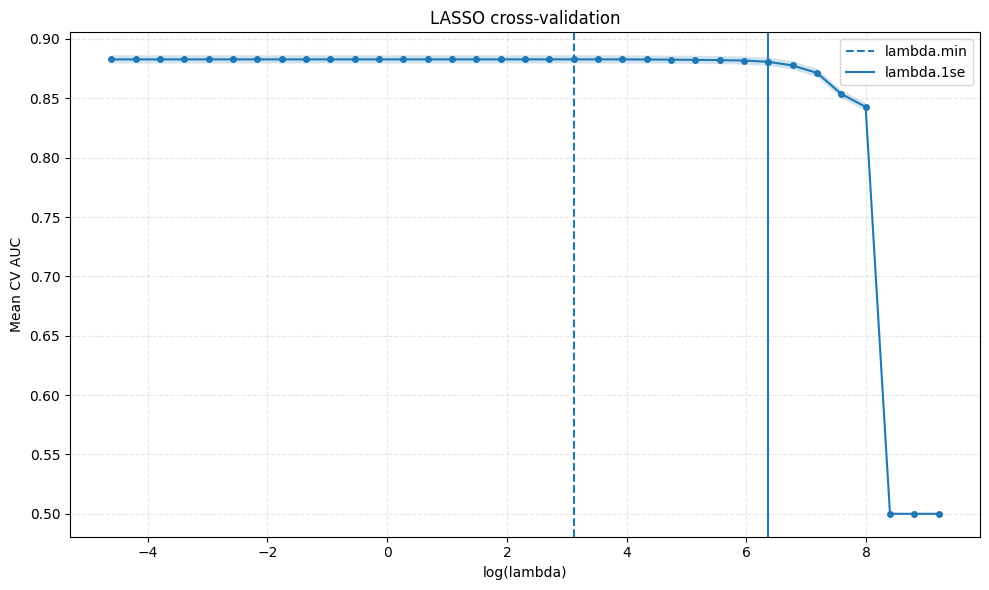

In [ ]:
plot_lasso_cv_results(
    lasso_results
)

In [ ]:
def compute_lasso_coefficient_path(
    X,
    y,
    Cs,
    random_state=42
):
    rows = []

    for C in Cs:

        pipeline = make_lasso_pipeline(
            C=C,
            random_state=random_state
        )

        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                ConvergenceWarning
            )

            pipeline.fit(X, y)

        coefficients = (
            pipeline
            .named_steps["lasso"]
            .coef_[0]
        )

        for feature, coefficient in zip(
            X.columns,
            coefficients
        ):
            rows.append({
                "Variable": feature,
                "C": C,
                "Lambda": 1.0 / C,
                "Log Lambda": np.log(
                    1.0 / C
                ),
                "Coefficient": coefficient
            })

    return pd.DataFrame(rows)

In [ ]:
coefficient_path = (
    compute_lasso_coefficient_path(
        X=X_train_selection,
        y=y_train_selection,
        Cs=lasso_results[
            "cv_results"
        ]["C"].to_numpy(),
        random_state=RANDOM_STATE
    )
)

In [ ]:
def plot_coefficient_path(
    coefficient_path,
    lasso_results
):
    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    for feature in (
        coefficient_path[
            "Variable"
        ].unique()
    ):

        feature_data = (
            coefficient_path.loc[
                coefficient_path[
                    "Variable"
                ] == feature
            ]
            .sort_values(
                "Log Lambda"
            )
        )

        ax.plot(
            feature_data[
                "Log Lambda"
            ],
            feature_data[
                "Coefficient"
            ],
            label=feature
        )

    ax.axvline(
        np.log(
            lasso_results[
                "lambda_best"
            ]
        ),
        linestyle="--",
        label="lambda.min"
    )

    ax.axvline(
        np.log(
            lasso_results[
                "lambda_1se"
            ]
        ),
        linestyle="-",
        label="lambda.1se"
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_title(
        "LASSO coefficient paths"
    )

    ax.set_xlabel(
        "log(lambda)"
    )

    ax.set_ylabel(
        "Standardized coefficient"
    )

    ax.grid(
        linestyle="--",
        alpha=0.3
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

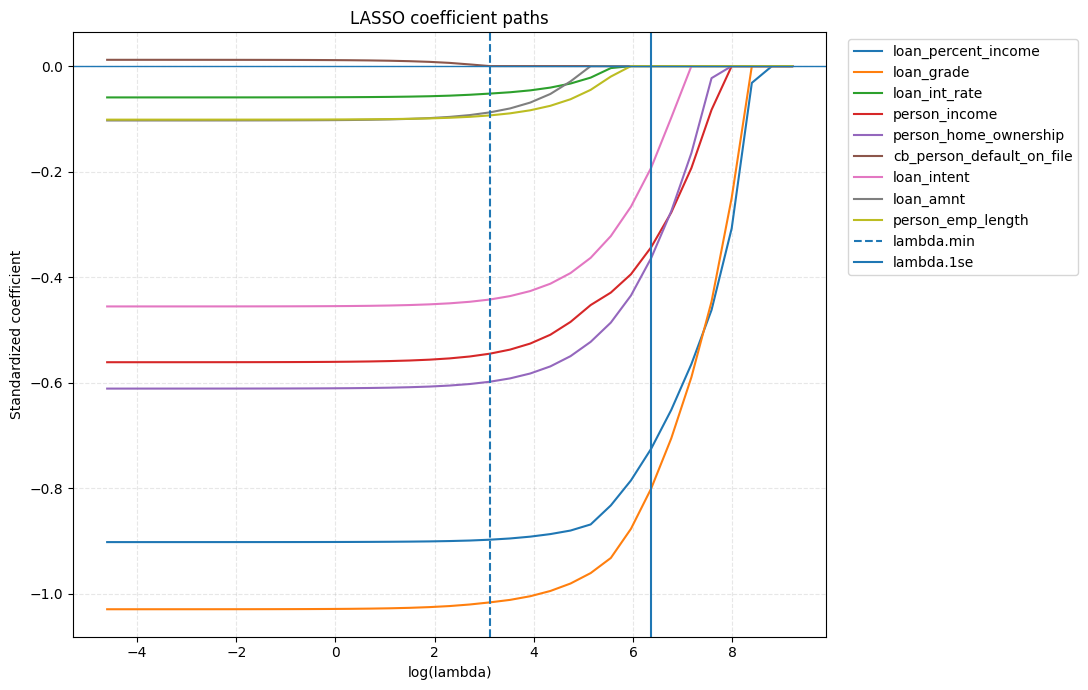

In [ ]:
plot_coefficient_path(
    coefficient_path=coefficient_path,
    lasso_results=lasso_results
)

## Coefficient Path

Coefficient path thể hiện sự thay đổi của hệ số khi $\lambda$ thay đổi:

```text
lambda nhỏ
    → nhiều hệ số khác 0

lambda tăng
    → hệ số bị co dần

lambda lớn
    → nhiều hệ số bằng 0
```

Coefficient path giúp quan sát:

- biến nào bị loại sớm;
- biến nào tồn tại đến mức regularization mạnh;
- biến nào có hệ số thay đổi mạnh.

## Hạn chế của LASSO

LASSO không được sử dụng làm tiêu chuẩn duy nhất vì:

- khi các biến tương quan, LASSO có thể chọn một biến và loại biến còn lại không ổn định;
- tập biến được chọn có thể thay đổi khi cách chia folds thay đổi;
- LASSO tối ưu mục tiêu dự báo, không trực tiếp tối ưu tính giải thích;
- LASSO không tự động xử lý prediction timestamp;
- LASSO không bảo đảm tìm được tổ hợp tốt nhất trong toàn bộ không gian mô hình.

Do đó, kết quả LASSO được so sánh với best-subset selection.

In [ ]:
selected_features_best = (
    lasso_results[
        "selected_best"
    ]
)

selected_features_1se = (
    lasso_results[
        "selected_1se"
    ]
)

if len(selected_features_1se) > 0:
    selected_features_proposed = (
        selected_features_1se
    )

    selection_rule = (
        "LASSO lambda.1se"
    )
else:
    warnings.warn(
        "lambda.1se không chọn biến nào. "
        "Tạm sử dụng danh sách lambda.min."
    )

    selected_features_proposed = (
        selected_features_best
    )

    selection_rule = (
        "LASSO lambda.min fallback"
    )

print(
    "Quy tắc lựa chọn:",
    selection_rule
)

print(
    "Các biến được đề xuất:"
)

print(
    selected_features_proposed
)

Quy tắc lựa chọn: LASSO lambda.1se
Các biến được đề xuất:
['loan_percent_income', 'loan_grade', 'person_income', 'person_home_ownership', 'loan_intent']


## VIF

In [ ]:
def calculate_vif(X):
    """
    Tính VIF trên các biến thực sự đưa vào mô hình.
    Không báo cáo VIF của intercept.
    """

    columns = list(X.columns)

    if len(columns) == 0:
        return pd.DataFrame(
            columns=["Variable", "VIF"]
        )

    if len(columns) == 1:
        return pd.DataFrame({
            "Variable": columns,
            "VIF": [1.0]
        })

    X_numeric = (
        X.astype(float)
        .copy()
    )

    X_with_constant = sm.add_constant(
        X_numeric,
        has_constant="add"
    )

    rows = []

    for index, variable in enumerate(
        X_with_constant.columns
    ):
        if variable == "const":
            continue

        try:
            vif = variance_inflation_factor(
                X_with_constant.values,
                index
            )

        except Exception:
            vif = np.inf

        rows.append({
            "Variable": variable,
            "VIF": float(vif)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
vif_selected = calculate_vif(
    train_woe_dataset[
        selected_features_proposed
    ]
)

display(
    vif_selected.round(4)
)

,Variable,VIF
0,person_income,1.1592
1,loan_percent_income,1.1196
2,person_home_ownership,1.0620
3,loan_grade,1.0184
4,loan_intent,1.0043


In [ ]:
high_vif_features = (
    vif_selected.loc[
        vif_selected["VIF"] > 5,
        "Variable"
    ]
    .tolist()
)

if high_vif_features:
    print(
        "Các biến có VIF > 5 cần rà soát:"
    )
    print(high_vif_features)
else:
    print(
        "Không có biến được chọn "
        "có VIF > 5."
    )

Không có biến được chọn có VIF > 5.


In [ ]:
feature_selection_result = (
    feature_screening_table[
        [
            "Variable",
            "Type",
            "IV",
            "Pass IV",
            "Business excluded",
            "Candidate for LASSO",
            "Decision"
        ]
    ]
    .copy()
)

feature_selection_result[
    "Selected lambda.min"
] = (
    feature_selection_result[
        "Variable"
    ]
    .isin(
        selected_features_best
    )
)

feature_selection_result[
    "Selected lambda.1se"
] = (
    feature_selection_result[
        "Variable"
    ]
    .isin(
        selected_features_1se
    )
)

feature_selection_result[
    "Proposed final feature"
] = (
    feature_selection_result[
        "Variable"
    ]
    .isin(
        selected_features_proposed
    )
)

feature_selection_result = (
    feature_selection_result
    .merge(
        vif_selected,
        on="Variable",
        how="left"
    )
    .sort_values(
        [
            "Proposed final feature",
            "IV"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

display(
    feature_selection_result.style.format({
        "IV": "{:.6f}",
        "VIF": "{:.4f}"
    })
)

,Variable,Type,IV,Pass IV,Business excluded,Candidate for LASSO,Decision,Selected lambda.min,Selected lambda.1se,Proposed final feature,VIF
0,loan_percent_income,numerical,0.952602,True,False,True,Giữ: đưa vào LASSO,True,True,True,1.1196
1,loan_grade,categorical,0.865536,True,False,True,Giữ: đưa vào LASSO,True,True,True,1.0184
2,person_income,numerical,0.507781,True,False,True,Giữ: đưa vào LASSO,True,True,True,1.1592
3,person_home_ownership,categorical,0.374315,True,False,True,Giữ: đưa vào LASSO,True,True,True,1.0620
4,loan_intent,categorical,0.104165,True,False,True,Giữ: đưa vào LASSO,True,True,True,1.0043
5,loan_int_rate,numerical,0.687478,True,False,True,Giữ: đưa vào LASSO,True,False,False,nan
6,cb_person_default_on_file,categorical,0.166233,True,False,True,Giữ: đưa vào LASSO,False,False,False,nan
7,loan_amnt,numerical,0.096976,True,False,True,Giữ: đưa vào LASSO,True,False,False,nan
8,person_emp_length,numerical,0.063267,True,False,True,Giữ: đưa vào LASSO,True,False,False,nan
9,person_age,numerical,0.010366,False,False,False,Loại: IV < 0.02,False,False,False,nan


In [ ]:
# ============================================================
# DỮ LIỆU BIN VÀ WOE
# ============================================================

train_bin_dataset.to_csv(
    OUTPUT_DIR / "train_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_bin_dataset.to_csv(
    OUTPUT_DIR / "test_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

train_woe_dataset.to_csv(
    OUTPUT_DIR / "train_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_woe_dataset.to_csv(
    OUTPUT_DIR / "test_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

# ============================================================
# BINNING VÀ DIAGNOSTIC
# ============================================================

iv_summary_train.to_csv(
    OUTPUT_DIR / "iv_summary_train.csv",
    index=False,
    encoding="utf-8-sig"
)

mapping_check.to_csv(
    OUTPUT_DIR / "bin_woe_mapping_check.csv",
    index=False,
    encoding="utf-8-sig"
)

train_diagnostic_table.to_csv(
    OUTPUT_DIR / "woe_diagnostic_train.csv",
    index=False,
    encoding="utf-8-sig"
)

train_warning_table.to_csv(
    OUTPUT_DIR / "woe_warning_train.csv",
    index=False,
    encoding="utf-8-sig"
)

unseen_category_check.to_csv(
    OUTPUT_DIR / "unseen_category_check.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FEATURE SELECTION
# ============================================================

feature_screening_table.to_csv(
    OUTPUT_DIR / "feature_screening_train.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "cv_results"
].to_csv(
    OUTPUT_DIR / "lasso_cv_results.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "coefficients_best"
].to_csv(
    OUTPUT_DIR
    / "lasso_coefficients_lambda_min.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "coefficients_1se"
].to_csv(
    OUTPUT_DIR
    / "lasso_coefficients_lambda_1se.csv",
    index=False,
    encoding="utf-8-sig"
)

coefficient_path.to_csv(
    OUTPUT_DIR
    / "lasso_coefficient_path.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_selected.to_csv(
    OUTPUT_DIR
    / "vif_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_selection_result.to_csv(
    OUTPUT_DIR
    / "feature_selection_result.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# LƯU BINNING MODELS FIT TỪ TRAIN
# ============================================================

joblib.dump(
    binning_models,
    OUTPUT_DIR
    / "optimal_binning_models_train.joblib"
)

['/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/optimal_binning_models_train.joblib']

In [ ]:
feature_selection_package = {
    "target": TARGET,
    "model_context": MODEL_CONTEXT,
    "business_exclude": (
        BUSINESS_EXCLUDE
    ),
    "iv_threshold": IV_THRESHOLD,
    "candidate_features": (
        candidate_features
    ),
    "selected_lambda_min": (
        selected_features_best
    ),
    "selected_lambda_1se": (
        selected_features_1se
    ),
    "selected_features_proposed": (
        selected_features_proposed
    ),
    "selection_rule": selection_rule,
    "C_best": lasso_results[
        "C_best"
    ],
    "C_1se": lasso_results[
        "C_1se"
    ],
    "lambda_best": lasso_results[
        "lambda_best"
    ],
    "lambda_1se": lasso_results[
        "lambda_1se"
    ],
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE
}

joblib.dump(
    feature_selection_package,
    OUTPUT_DIR
    / "feature_selection_package.joblib"
)

with open(
    OUTPUT_DIR
    / "selected_features.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        feature_selection_package,
        file,
        ensure_ascii=False,
        indent=4
    )

# Best-Subset Selection

Sau IV screening còn chín biến ứng viên.

Số tổ hợp khác rỗng:

$$
2^9-1=511.
$$

511 tổ hợp đủ nhỏ để đánh giá toàn bộ không gian mô hình.


Quy trình đánh giá mỗi tổ hợp:

```text
Tổ hợp biến
        │
        ▼
Tính VIF
        │
        ├── max VIF > 5 → loại tổ hợp
        └── max VIF ≤ 5 → tiếp tục
                    │
                    ▼
        10-fold cross-validation
                    │
                    ▼
        Dự báo out-of-fold
                    │
                    ▼
        AUC, Gini, Brier và stability
```

## Các chỉ tiêu đánh giá tổ hợp

Với mỗi tổ hợp, quy trình ghi nhận:

- số lượng biến;
- VIF lớn nhất;
- pooled out-of-fold AUC;
- pooled out-of-fold Gini;
- out-of-fold Brier score;
- AUC trung bình giữa các folds;
- độ lệch chuẩn AUC;
- sai số chuẩn AUC;
- AUC nhỏ nhất giữa các folds;
- AUC lớn nhất giữa các folds;


Mô hình logistic trong bước selection có dạng:

$$
\operatorname{logit}(p_i)
=
\beta_0+
\sum_{j\in S}\beta_jWOE_{ij},
$$

trong đó:

- $S$ là tập biến của tổ hợp đang xét;
- $p_i$ là xác suất vỡ nợ;
- $WOE_{ij}$ là giá trị WOE của biến \(j\).

Mô hình này chỉ phục vụ feature selection, chưa phải mô hình logistic cuối cùng.

## Out-of-Fold Prediction

Mỗi quan sát trong tập train được dự báo bởi mô hình không sử dụng chính quan sát đó để fit.

Sau cross-validation, mỗi quan sát có xác suất:

$$
\widehat p_{i,\mathrm{OOF}}.
$$

Pooled OOF AUC:

$$
AUC_{\mathrm{OOF}}
=
AUC
\left(
y,\widehat p_{\mathrm{OOF}}
\right).
$$

Pooled OOF Gini:

$$
Gini_{\mathrm{OOF}}
=
2AUC_{\mathrm{OOF}}-1.
$$

Brier score:

$$
Brier
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\widehat p_i)^2.
$$

Trong đó:

- AUC và Gini đánh giá khả năng xếp hạng;
- Brier score đánh giá sai số xác suất;
- AUC/Gini càng lớn càng tốt;
- Brier score càng nhỏ càng tốt.

## AUC trung bình và sai số chuẩn

AUC trung bình giữa các folds:

$$
\overline{AUC}
=
\frac{1}{K}
\sum_{k=1}^{K}AUC_k.
$$

Độ lệch chuẩn:

$$
SD(AUC)
=
\sqrt{
\frac{
\sum_{k=1}^{K}
(AUC_k-\overline{AUC})^2
}{
K-1
}
}.
$$

Sai số chuẩn:

$$
SE(AUC)
=
\frac{SD(AUC)}{\sqrt{K}}.
$$

Với:

$$
K=10.
$$

## Kiểm tra dấu hệ số

WOE được định nghĩa:

$$
WOE
=
\ln
\left(
\frac{DistGood}{DistBad}
\right).
$$

Trong khi `loan_status = 1` là vỡ nợ, nên kỳ vọng thông thường:

$$
\beta_j<0.
$$

Diễn giải:

```text
WOE tăng
    → nghiêng nhiều hơn về nhóm Good
    → xác suất default giảm
    → hệ số logistic thường âm
```

## Mô hình Max-Gini

Mô hình max-Gini là tổ hợp có pooled OOF Gini cao nhất trong số các tổ hợp thỏa mãn ràng buộc VIF.

Tiêu chí:

$$
\max Gini_{\mathrm{OOF}}.
$$

Khi nhiều mô hình có hiệu năng gần tương đương, ưu tiên:

1. ít biến hơn;
2. VIF thấp hơn;
3. dễ giải thích hơn;
4. biến có sẵn tại prediction timestamp.

## Quy tắc 1-SE

Ngưỡng 1-SE:

$$
AUC_{\mathrm{1SE}}
=
AUC_{\max}
-
SE(AUC_{\max}).
$$

Các mô hình có AUC trung bình lớn hơn hoặc bằng ngưỡng này được xem là gần tương đương với mô hình tốt nhất.

Trong nhóm đó, lựa chọn:

1. mô hình có ít biến nhất;
2. nếu cùng số biến, chọn AUC cao hơn;
3. nếu vẫn tương đương, chọn OOF Gini cao hơn;
4. nếu vẫn tương đương, chọn VIF thấp hơn.

Best-subset 1-SE là ứng viên chính cho scorecard về mặt thống kê.

# Pre-Decision Best-Subset

Nhánh pre-decision loại:

```text
loan_grade
loan_int_rate
```

Sau đó thực hiện lại toàn bộ best-subset selection trên các biến còn lại.

Không nên:

```text
Chọn mô hình full
        │
        ▼
Xóa loan_grade và loan_int_rate
```


Quy trìnhz;

```text
Pre-decision candidates
        │
        ▼
Tạo toàn bộ tổ hợp
        │
        ▼
Kiểm tra VIF
        │
        ▼
Cross-validation
        │
        ▼
Chọn max-Gini và 1-SE
```

Sau khi loại grade và lãi suất còn bảy biến, tương ứng:

$$
2^7-1=127
$$

tổ hợp khác rỗng.

# Bốn tập biến ưu tiên

Bốn tập biến được ưu tiên cho bước xây dựng mô hình:

```text
Full WOE
Best-subset 1-SE
LASSO lambda.1se
Pre-decision 1-SE
```

| Tập biến | Vai trò |
|---|---|
| Full WOE | Benchmark |
| Best-subset 1-SE | Ứng viên scorecard chính về mặt thống kê |
| LASSO lambda.1se | Đối chiếu bằng regularization |
| Pre-decision 1-SE | Ứng viên hợp lệ trước quyết định tín dụng |

Các tập này sẽ được sử dụng để xây dựng và so sánh:

```text
Full WOE Logistic
Best-Subset Logistic
LASSO Logistic
Pre-Decision Logistic
```

Mô hình có Gini cao nhất chưa chắc là mô hình nên triển khai.

Tính hợp lệ về prediction timestamp và khả năng giải thích cần được xem xét cùng hiệu năng.

# Đánh giá sự đồng thuận giữa các phương pháp

Một ma trận lựa chọn biến được tạo để xác định mỗi biến xuất hiện trong phương pháp nào.

Ví dụ:

| Variable | Full | Best-subset | LASSO | Pre-decision |
|---|---:|---:|---:|---:|
| Variable A | True | True | True | True |
| Variable B | True | False | True | False |
| Variable C | True | True | False | True |

Nếu một biến được giữ bởi cả:

```text
Best-subset 1-SE
LASSO lambda.1se
Pre-decision 1-SE
```

thì đây là tín hiệu cho thấy biến:

- có khả năng phân biệt;
- đóng góp trong mô hình đa biến;
- ít phụ thuộc vào phương pháp lựa chọn;
- có tính ổn định tương đối cao.

Một biến chỉ xuất hiện trong một phương pháp cần được rà soát thêm về:

- IV;
- VIF;
- dấu hệ số;
- prediction timestamp;
- ý nghĩa nghiệp vụ;
- mức cải thiện Gini;


In [ ]:
from itertools import combinations

# ============================================================
# CẤU HÌNH BỔ SUNG CHO BEST-SUBSET
# ============================================================

VIF_THRESHOLD = 5.0
BEST_SUBSET_CV_FOLDS = 10

PRE_DECISION_EXCLUDE = [
    "loan_grade",
    "loan_int_rate"
]

# Full WOE: tất cả biến vượt IV và không phải biến WOE hằng.
# Không loại loan_grade/loan_int_rate ở tập Full vì đây là
# benchmark "all available".
full_woe_features = (
    feature_screening_table.loc[
        (
            feature_screening_table["Pass IV"]
            & ~feature_screening_table["Constant WOE"]
        ),
        "Variable"
    ]
    .tolist()
)

pre_decision_candidate_features = [
    feature
    for feature in full_woe_features
    if feature not in PRE_DECISION_EXCLUDE
]

print("Full WOE features:")
print(full_woe_features)

print("\nPre-decision candidate features:")
print(pre_decision_candidate_features)

print(
    "\nSố tổ hợp Full:",
    2 ** len(full_woe_features) - 1
)

print(
    "Số tổ hợp Pre-decision:",
    2 ** len(pre_decision_candidate_features) - 1
)


Full WOE features:
['loan_percent_income', 'loan_grade', 'loan_int_rate', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt', 'person_emp_length']

Pre-decision candidate features:
['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt', 'person_emp_length']

Số tổ hợp Full: 511
Số tổ hợp Pre-decision: 127


In [ ]:
def fast_vif_table(
    X,
    singular_tolerance=1e-10
):
    """
    Tính VIF nhanh từ nghịch đảo ma trận tương quan.

    Hàm này dùng để rà soát hàng trăm tổ hợp biến.
    Bảng VIF cuối cùng vẫn có thể đối chiếu bằng
    calculate_vif() đã định nghĩa ở phần trước.
    """

    columns = list(X.columns)

    if len(columns) == 0:
        return pd.DataFrame(
            columns=["Variable", "VIF"]
        )

    if len(columns) == 1:
        return pd.DataFrame({
            "Variable": columns,
            "VIF": [1.0]
        })

    values = X.astype(float).to_numpy()

    standard_deviation = values.std(
        axis=0,
        ddof=1
    )

    if np.any(
        standard_deviation <= singular_tolerance
    ):
        return pd.DataFrame({
            "Variable": columns,
            "VIF": [np.inf] * len(columns)
        })

    correlation_matrix = np.corrcoef(
        values,
        rowvar=False
    )

    if not np.isfinite(
        correlation_matrix
    ).all():
        return pd.DataFrame({
            "Variable": columns,
            "VIF": [np.inf] * len(columns)
        })

    eigenvalues = np.linalg.eigvalsh(
        correlation_matrix
    )

    if np.min(eigenvalues) <= singular_tolerance:
        return pd.DataFrame({
            "Variable": columns,
            "VIF": [np.inf] * len(columns)
        })

    inverse_correlation = np.linalg.inv(
        correlation_matrix
    )

    vif_values = np.diag(
        inverse_correlation
    )

    return (
        pd.DataFrame({
            "Variable": columns,
            "VIF": vif_values.astype(float)
        })
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )


In [ ]:
def evaluate_logistic_subset_cv(
    X,
    y,
    feature_subset,
    cv_splits,
    random_state=42
):
    """
    Đánh giá một tổ hợp biến bằng logistic regression
    không phạt trên các fold của tập train.

    Đây chỉ là mô hình nội bộ phục vụ feature selection,
    chưa phải mô hình logistic cuối cùng.

    Chỉ số chính:
    - pooled out-of-fold AUC/Gini;
    - mean AUC và SE theo fold;
    - OOF Brier score;
    - độ ổn định dấu hệ số.
    """

    feature_subset = tuple(
        feature_subset
    )

    X_subset = (
        X.loc[:, list(feature_subset)]
        .astype(float)
    )

    oof_probability = np.full(
        len(X_subset),
        np.nan,
        dtype=float
    )

    fold_auc = []
    fold_coefficients = []
    convergence_ok = True

    for train_index, valid_index in cv_splits:

        X_fold_train = X_subset.iloc[
            train_index
        ]

        y_fold_train = y.iloc[
            train_index
        ]

        X_fold_valid = X_subset.iloc[
            valid_index
        ]

        y_fold_valid = y.iloc[
            valid_index
        ]

        model = LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000,
            tol=1e-8,
            random_state=random_state
        )

        try:
            with warnings.catch_warnings(
                record=True
            ) as caught_warnings:

                warnings.simplefilter(
                    "always",
                    ConvergenceWarning
                )

                model.fit(
                    X_fold_train,
                    y_fold_train
                )

                if any(
                    issubclass(
                        warning.category,
                        ConvergenceWarning
                    )
                    for warning in caught_warnings
                ):
                    convergence_ok = False

            probability = model.predict_proba(
                X_fold_valid
            )[:, 1]

        except Exception as error:
            return {
                "Status": (
                    "ERROR: "
                    f"{type(error).__name__}"
                ),
                "Converged in all folds": False
            }

        oof_probability[
            valid_index
        ] = probability

        fold_auc.append(
            roc_auc_score(
                y_fold_valid,
                probability
            )
        )

        fold_coefficients.append(
            model.coef_[0].copy()
        )

    if np.isnan(
        oof_probability
    ).any():
        return {
            "Status": "ERROR: incomplete OOF",
            "Converged in all folds": False
        }

    pooled_auc = roc_auc_score(
        y,
        oof_probability
    )

    fold_auc = np.asarray(
        fold_auc,
        dtype=float
    )

    coefficient_matrix = np.vstack(
        fold_coefficients
    )

    positive_sign_rate = (
        coefficient_matrix > 0
    ).mean(axis=0)

    return {
        "Status": "OK",
        "Converged in all folds": bool(
            convergence_ok
        ),
        "Pooled OOF AUC": float(
            pooled_auc
        ),
        "Pooled OOF Gini": float(
            2.0 * pooled_auc - 1.0
        ),
        "Mean CV AUC": float(
            fold_auc.mean()
        ),
        "SD CV AUC": float(
            fold_auc.std(ddof=1)
        ),
        "SE CV AUC": float(
            fold_auc.std(ddof=1)
            / np.sqrt(len(fold_auc))
        ),
        "Minimum fold AUC": float(
            fold_auc.min()
        ),
        "Maximum fold AUC": float(
            fold_auc.max()
        ),
        "OOF Brier": float(
            np.mean(
                (
                    y.to_numpy(dtype=float)
                    - oof_probability
                ) ** 2
            )
        ),
        "All coefficients non-positive": bool(
            np.all(coefficient_matrix <= 0)
        ),
        "Maximum positive-sign rate": float(
            positive_sign_rate.max()
        ),
        "Maximum absolute coefficient": float(
            np.abs(
                coefficient_matrix
            ).max()
        )
    }


In [ ]:
def exhaustive_best_subset_selection(
    X,
    y,
    candidate_features,
    vif_threshold=5.0,
    n_splits=10,
    random_state=42,
    progress_every=50
):
    """
    Xét toàn bộ 2^p - 1 tổ hợp biến.

    Một tổ hợp:
    - bị loại trước CV nếu max VIF > vif_threshold;
    - nếu đạt VIF, được đánh giá bằng cùng một bộ
      Stratified K-fold splits;
    - test set không được sử dụng.
    """

    candidate_features = list(
        candidate_features
    )

    if len(candidate_features) == 0:
        raise ValueError(
            "Không có biến ứng viên cho best-subset."
        )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    cv_splits = list(
        cv.split(
            X[candidate_features],
            y
        )
    )

    total_subsets = (
        2 ** len(candidate_features) - 1
    )

    rows = []
    processed = 0

    for subset_size in range(
        1,
        len(candidate_features) + 1
    ):

        for feature_subset in combinations(
            candidate_features,
            subset_size
        ):

            processed += 1

            X_subset = X.loc[
                :,
                list(feature_subset)
            ]

            vif_table = fast_vif_table(
                X_subset
            )

            maximum_vif = float(
                vif_table["VIF"].max()
            )

            base_result = {
                "Features": tuple(
                    feature_subset
                ),
                "Feature string": " | ".join(
                    feature_subset
                ),
                "Number of features": int(
                    subset_size
                ),
                "Maximum VIF": maximum_vif,
                "Pass VIF": bool(
                    maximum_vif
                    <= vif_threshold
                )
            }

            if not base_result["Pass VIF"]:

                base_result.update({
                    "Status": "REJECTED_VIF",
                    "Converged in all folds": False
                })

                rows.append(base_result)

            else:

                cv_result = (
                    evaluate_logistic_subset_cv(
                        X=X,
                        y=y,
                        feature_subset=(
                            feature_subset
                        ),
                        cv_splits=cv_splits,
                        random_state=random_state
                    )
                )

                base_result.update(
                    cv_result
                )

                rows.append(base_result)

            if (
                progress_every
                and processed % progress_every == 0
            ):
                print(
                    f"Đã xử lý "
                    f"{processed}/{total_subsets} "
                    f"tổ hợp."
                )

    result = pd.DataFrame(rows)

    metric_columns = [
        "Pooled OOF AUC",
        "Pooled OOF Gini",
        "Mean CV AUC",
        "SD CV AUC",
        "SE CV AUC",
        "Minimum fold AUC",
        "Maximum fold AUC",
        "OOF Brier",
        "Maximum positive-sign rate",
        "Maximum absolute coefficient"
    ]

    for column in metric_columns:
        if column not in result.columns:
            result[column] = np.nan

    return result


def select_subset_by_one_se(
    subset_results
):
    """
    Chọn hai kết quả:

    1. max_gini:
       tổ hợp có pooled OOF Gini cao nhất;

    2. one_se:
       tổ hợp nhỏ nhất có Mean CV AUC không thấp hơn
       Mean CV AUC tốt nhất trừ đi một SE của mô hình tốt nhất.

    Khi bằng số biến:
    - ưu tiên pooled OOF Gini cao hơn;
    - sau đó ưu tiên VIF thấp hơn.
    """

    usable = (
        subset_results.loc[
            (
                subset_results["Status"] == "OK"
            )
            & subset_results[
                "Converged in all folds"
            ].fillna(False)
        ]
        .dropna(
            subset=[
                "Pooled OOF Gini",
                "Mean CV AUC",
                "SE CV AUC"
            ]
        )
        .copy()
    )

    if usable.empty:
        raise RuntimeError(
            "Không có tổ hợp hợp lệ để lựa chọn."
        )

    max_gini_row = (
        usable
        .sort_values(
            [
                "Pooled OOF Gini",
                "Number of features",
                "Maximum VIF"
            ],
            ascending=[
                False,
                True,
                True
            ]
        )
        .iloc[0]
    )

    one_se_threshold = (
        float(max_gini_row["Mean CV AUC"])
        - float(max_gini_row["SE CV AUC"])
    )

    eligible = usable.loc[
        usable["Mean CV AUC"]
        >= one_se_threshold
    ].copy()

    one_se_row = (
        eligible
        .sort_values(
            [
                "Number of features",
                "Pooled OOF Gini",
                "Maximum VIF"
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .iloc[0]
    )

    return {
        "max_gini": max_gini_row,
        "one_se": one_se_row,
        "one_se_threshold": float(
            one_se_threshold
        ),
        "eligible_models": int(
            len(eligible)
        )
    }


In [ ]:
# ============================================================
# CHẠY BEST-SUBSET TRÊN TẬP TRAIN WOE
# ============================================================
#
all_subset_results = (
    exhaustive_best_subset_selection(
        X=train_woe_dataset[
            full_woe_features
        ].astype(float),
        y=train_woe_dataset[
            TARGET
        ].astype(int),
        candidate_features=(
            full_woe_features
        ),
        vif_threshold=VIF_THRESHOLD,
        n_splits=BEST_SUBSET_CV_FOLDS,
        random_state=RANDOM_STATE,
        progress_every=50
    )
)

print(
    "Tổng số tổ hợp:",
    len(all_subset_results)
)

print(
    "Số tổ hợp đạt VIF và CV:",
    (
        all_subset_results["Status"]
        == "OK"
    ).sum()
)

display(
    all_subset_results.loc[
        all_subset_results["Status"] == "OK"
    ]
    .sort_values(
        "Pooled OOF Gini",
        ascending=False
    )
    .head(15)
    .round(6)
)


Đã xử lý 50/511 tổ hợp.
Đã xử lý 100/511 tổ hợp.
Đã xử lý 150/511 tổ hợp.
Đã xử lý 200/511 tổ hợp.
Đã xử lý 250/511 tổ hợp.
Đã xử lý 300/511 tổ hợp.
Đã xử lý 350/511 tổ hợp.
Đã xử lý 400/511 tổ hợp.
Đã xử lý 450/511 tổ hợp.
Đã xử lý 500/511 tổ hợp.
Tổng số tổ hợp: 511
Số tổ hợp đạt VIF và CV: 511


,Features,Feature string,Number of features,Maximum VIF,Pass VIF,Status,Converged in all folds,Pooled OOF AUC,Pooled OOF Gini,Mean CV AUC,SD CV AUC,SE CV AUC,Minimum fold AUC,Maximum fold AUC,OOF Brier,All coefficients non-positive,Maximum positive-sign rate,Maximum absolute coefficient
468,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,7,4.103720,True,OK,True,0.883127,0.766254,0.883210,0.010884,0.003442,0.868190,0.907099,0.093856,True,0.0,1.432586
501,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,8,4.220851,True,OK,True,0.883082,0.766164,0.883172,0.010888,0.003443,0.868166,0.907123,0.093857,False,1.0,1.432600
404,"(loan_percent_income, loan_grade, person_incom...",loan_percent_income | loan_grade | person_inco...,6,1.647384,True,OK,True,0.883058,0.766116,0.883133,0.010889,0.003443,0.868181,0.906949,0.093807,True,0.0,1.432434
480,"(loan_percent_income, loan_grade, person_incom...",loan_percent_income | loan_grade | person_inco...,7,1.647387,True,OK,True,0.883008,0.766016,0.883076,0.010873,0.003438,0.868223,0.906928,0.093811,False,0.9,1.432432
504,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,8,4.103728,True,OK,True,0.882743,0.765486,0.882822,0.010982,0.003473,0.867173,0.907050,0.093443,True,0.0,1.440725
510,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,9,4.220853,True,OK,True,0.882700,0.765400,0.882775,0.010988,0.003475,0.867159,0.907063,0.093443,False,1.0,1.440737
382,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,6,4.095695,True,OK,True,0.882689,0.765379,0.882827,0.010759,0.003402,0.867413,0.906310,0.093951,True,0.0,1.438474
483,"(loan_percent_income, loan_grade, person_incom...",loan_percent_income | loan_grade | person_inco...,7,1.647601,True,OK,True,0.882655,0.765310,0.882731,0.010954,0.003464,0.867246,0.906828,0.093395,True,0.0,1.440602
465,"(loan_percent_income, loan_grade, loan_int_rat...",loan_percent_income | loan_grade | loan_int_ra...,7,4.212475,True,OK,True,0.882632,0.765264,0.882773,0.010748,0.003399,0.867449,0.906308,0.093954,False,1.0,1.438486
507,"(loan_percent_income, loan_grade, person_incom...",loan_percent_income | loan_grade | person_inco...,8,1.647604,True,OK,True,0.882615,0.765230,0.882697,0.010957,0.003465,0.867250,0.906823,0.093399,False,0.9,1.440602


In [ ]:
# ============================================================
# 1. BEST-SUBSET TRÊN TOÀN BỘ BIẾN VƯỢT IV
# ============================================================

best_subset_selection = (
    select_subset_by_one_se(
        all_subset_results
    )
)

best_subset_features_max_gini = list(
    best_subset_selection[
        "max_gini"
    ]["Features"]
)

best_subset_features_proposed = list(
    best_subset_selection[
        "one_se"
    ]["Features"]
)

# ============================================================
# 2. PRE-DECISION BEST-SUBSET
# ============================================================

pre_decision_subset_results = (
    all_subset_results.loc[
        all_subset_results[
            "Features"
        ].map(
            lambda selected:
            set(selected).isdisjoint(
                PRE_DECISION_EXCLUDE
            )
        )
    ]
    .copy()
    .reset_index(drop=True)
)

pre_decision_selection = (
    select_subset_by_one_se(
        pre_decision_subset_results
    )
)

pre_decision_features_max_gini = list(
    pre_decision_selection[
        "max_gini"
    ]["Features"]
)

pre_decision_features_proposed = list(
    pre_decision_selection[
        "one_se"
    ]["Features"]
)

print("=" * 72)
print("BEST-SUBSET — ALL AVAILABLE")
print("=" * 72)

print(
    "Max-Gini features:",
    best_subset_features_max_gini
)

print(
    "1-SE proposed features:",
    best_subset_features_proposed
)

print(
    "1-SE threshold:",
    round(
        best_subset_selection[
            "one_se_threshold"
        ],
        6
    )
)

print("\n" + "=" * 72)
print("BEST-SUBSET — PRE-DECISION")
print("=" * 72)

print(
    "Các biến bị cấm:",
    PRE_DECISION_EXCLUDE
)

print(
    "Max-Gini features:",
    pre_decision_features_max_gini
)

print(
    "1-SE proposed features:",
    pre_decision_features_proposed
)

print(
    "1-SE threshold:",
    round(
        pre_decision_selection[
            "one_se_threshold"
        ],
        6
    )
)


BEST-SUBSET — ALL AVAILABLE
Max-Gini features: ['loan_percent_income', 'loan_grade', 'loan_int_rate', 'person_income', 'person_home_ownership', 'loan_intent', 'loan_amnt']
1-SE proposed features: ['loan_percent_income', 'loan_grade', 'person_income', 'person_home_ownership', 'loan_intent']
1-SE threshold: 0.879768

BEST-SUBSET — PRE-DECISION
Các biến bị cấm: ['loan_grade', 'loan_int_rate']
Max-Gini features: ['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt', 'person_emp_length']
1-SE proposed features: ['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt']
1-SE threshold: 0.821841


In [ ]:
def subset_selection_to_table(
    selection_result,
    context_name
):
    rows = []

    for rule_name, key in [
        ("Maximum pooled OOF Gini", "max_gini"),
        ("One-standard-error", "one_se")
    ]:

        row = selection_result[key]

        rows.append({
            "Context": context_name,
            "Selection rule": rule_name,
            "Number of features": int(
                row["Number of features"]
            ),
            "Features": " | ".join(
                row["Features"]
            ),
            "Pooled OOF AUC": float(
                row["Pooled OOF AUC"]
            ),
            "Pooled OOF Gini": float(
                row["Pooled OOF Gini"]
            ),
            "Mean CV AUC": float(
                row["Mean CV AUC"]
            ),
            "SE CV AUC": float(
                row["SE CV AUC"]
            ),
            "OOF Brier": float(
                row["OOF Brier"]
            ),
            "Maximum VIF": float(
                row["Maximum VIF"]
            ),
            "All coefficients non-positive": bool(
                row[
                    "All coefficients non-positive"
                ]
            ),
            "Maximum positive-sign rate": float(
                row[
                    "Maximum positive-sign rate"
                ]
            )
        })

    return pd.DataFrame(rows)


subset_selection_summary = pd.concat(
    [
        subset_selection_to_table(
            best_subset_selection,
            "All available"
        ),
        subset_selection_to_table(
            pre_decision_selection,
            "Pre-decision"
        )
    ],
    ignore_index=True
)

display(
    subset_selection_summary.style.format({
        "Pooled OOF AUC": "{:.6f}",
        "Pooled OOF Gini": "{:.6f}",
        "Mean CV AUC": "{:.6f}",
        "SE CV AUC": "{:.6f}",
        "OOF Brier": "{:.6f}",
        "Maximum VIF": "{:.4f}",
        "Maximum positive-sign rate": "{:.1%}"
    })
)


,Context,Selection rule,Number of features,Features,Pooled OOF AUC,Pooled OOF Gini,Mean CV AUC,SE CV AUC,OOF Brier,Maximum VIF,All coefficients non-positive,Maximum positive-sign rate
0,All available,Maximum pooled OOF Gini,7,loan_percent_income | loan_grade | loan_int_rate | person_income | person_home_ownership | loan_intent | loan_amnt,0.883127,0.766254,0.883210,0.003442,0.093856,4.1037,True,0.0%
1,All available,One-standard-error,5,loan_percent_income | loan_grade | person_income | person_home_ownership | loan_intent,0.882572,0.765144,0.882678,0.003390,0.093903,1.1592,True,0.0%
2,Pre-decision,Maximum pooled OOF Gini,7,loan_percent_income | person_income | person_home_ownership | cb_person_default_on_file | loan_intent | loan_amnt | person_emp_length,0.825732,0.651464,0.825742,0.003900,0.114652,1.6191,True,0.0%
3,Pre-decision,One-standard-error,6,loan_percent_income | person_income | person_home_ownership | cb_person_default_on_file | loan_intent | loan_amnt,0.825182,0.650365,0.825215,0.003797,0.114875,1.6189,True,0.0%


In [ ]:
# ============================================================
# KHÓA BỐN TẬP BIẾN ĐỂ FIT MÔ HÌNH Ở GIAI ĐOẠN SAU
# ============================================================

model_feature_sets = {
    "full_woe": list(
        full_woe_features
    ),
    "best_subset_1se": list(
        best_subset_features_proposed
    ),
    "lasso_1se": list(
        selected_features_proposed
    ),
    "pre_decision_best_subset_1se": list(
        pre_decision_features_proposed
    )
}

vif_full_woe = calculate_vif(
    train_woe_dataset[
        model_feature_sets["full_woe"]
    ]
)

vif_best_subset = calculate_vif(
    train_woe_dataset[
        model_feature_sets[
            "best_subset_1se"
        ]
    ]
)

vif_lasso_1se = calculate_vif(
    train_woe_dataset[
        model_feature_sets[
            "lasso_1se"
        ]
    ]
)

vif_pre_decision = calculate_vif(
    train_woe_dataset[
        model_feature_sets[
            "pre_decision_best_subset_1se"
        ]
    ]
)

vif_tables_by_model = {
    "full_woe": vif_full_woe,
    "best_subset_1se": vif_best_subset,
    "lasso_1se": vif_lasso_1se,
    "pre_decision_best_subset_1se": (
        vif_pre_decision
    )
}

model_feature_set_rows = []

for model_name, selected_features in (
    model_feature_sets.items()
):

    current_vif = (
        vif_tables_by_model[model_name]
    )

    model_feature_set_rows.append({
        "Feature set": model_name,
        "Number of features": len(
            selected_features
        ),
        "Features": " | ".join(
            selected_features
        ),
        "Maximum VIF": (
            float(current_vif["VIF"].max())
            if not current_vif.empty
            else np.nan
        )
    })

model_feature_set_summary = pd.DataFrame(
    model_feature_set_rows
)

feature_set_membership = (
    iv_summary_train[
        ["Variable", "IV"]
    ]
    .copy()
)

for model_name, selected_features in (
    model_feature_sets.items()
):
    feature_set_membership[
        model_name
    ] = (
        feature_set_membership["Variable"]
        .isin(selected_features)
    )

display(
    model_feature_set_summary.style.format({
        "Maximum VIF": "{:.4f}"
    })
)

display(
    feature_set_membership.style.format({
        "IV": "{:.6f}"
    })
)

print(
    "\nĐã hoàn thiện bốn tập biến."
)

print(
    "Chưa fit bốn mô hình cuối cùng "
    "và chưa sử dụng tập test."
)


,Feature set,Number of features,Features,Maximum VIF
0,full_woe,9,loan_percent_income | loan_grade | loan_int_rate | person_income | person_home_ownership | cb_person_default_on_file | loan_intent | loan_amnt | person_emp_length,4.2209
1,best_subset_1se,5,loan_percent_income | loan_grade | person_income | person_home_ownership | loan_intent,1.1592
2,lasso_1se,5,loan_percent_income | loan_grade | person_income | person_home_ownership | loan_intent,1.1592
3,pre_decision_best_subset_1se,6,loan_percent_income | person_income | person_home_ownership | cb_person_default_on_file | loan_intent | loan_amnt,1.6189


,Variable,IV,full_woe,best_subset_1se,lasso_1se,pre_decision_best_subset_1se
0,loan_percent_income,0.952602,True,True,True,True
1,loan_grade,0.865536,True,True,True,False
2,loan_int_rate,0.687478,True,False,False,False
3,person_income,0.507781,True,True,True,True
4,person_home_ownership,0.374315,True,True,True,True
5,cb_person_default_on_file,0.166233,True,False,False,True
6,loan_intent,0.104165,True,True,True,True
7,loan_amnt,0.096976,True,False,False,True
8,person_emp_length,0.063267,True,False,False,False
9,person_age,0.010366,False,False,False,False



Đã hoàn thiện bốn tập biến.
Chưa fit bốn mô hình cuối cùng và chưa sử dụng tập test.


# Các tệp đầu ra

Kết quả feature selection được lưu tại:

```text
/content/drive/MyDrive/AIO 2026/Conquer/Data/
train_test_feature_selection/
feature_selection_outputs/
```

Các tệp chính:

```text
feature_screening_table.csv
full_feature_vif.csv
lasso_cv_results.csv
lasso_coefficients_lambda_min.csv
lasso_coefficients_lambda_1se.csv
lasso_coefficient_path.csv
best_subset_full_all_results.csv
best_subset_full_feasible_results.csv
best_subset_pre_decision_all_results.csv
best_subset_pre_decision_feasible_results.csv
model_feature_sets_summary.csv
preferred_feature_sets_vif.csv
feature_selection_matrix.csv
model_feature_sets.json
feature_selection_metadata.joblib
lasso_selector_lambda_min.joblib
lasso_selector_lambda_1se.joblib
feature_selection_outputs.xlsx
```

## Ý nghĩa các tệp Screening và LASSO

### `feature_screening_table.csv`

Tổng hợp:

- tên biến;
- IV;
- kết quả IV screening;
- biến WOE hằng;
- biến bị loại khỏi pre-decision;
- quyết định giữ hoặc loại.

### `full_feature_vif.csv`

Chứa VIF của toàn bộ biến vượt IV screening.

Dùng để chẩn đoán đa cộng tuyến của tập full, không dùng để loại biến tự động.

### `lasso_cv_results.csv`

Chứa kết quả theo từng giá trị \(C\) hoặc \(\lambda\):

- Mean CV AUC;
- SD CV AUC;
- SE CV AUC;
- Mean CV Gini.

Dùng để xác định `lambda.min` và `lambda.1se`.

### `lasso_coefficients_lambda_min.csv`

Chứa hệ số LASSO tại `lambda.min`.

### `lasso_coefficients_lambda_1se.csv`

Chứa hệ số LASSO tại `lambda.1se`.

### `lasso_coefficient_path.csv`

Chứa đường đi hệ số theo mức regularization.

## Ý nghĩa các tệp Best-Subset

### `best_subset_full_all_results.csv`

Chứa kết quả của toàn bộ tổ hợp trong tập ứng viên đầy đủ, gồm:

- tổ hợp vượt VIF;
- tổ hợp bị loại do VIF;
- tổ hợp fit thành công;
- tổ hợp gặp lỗi mô hình.

### `best_subset_full_feasible_results.csv`

Chỉ giữ các tổ hợp:

- thỏa mãn VIF;
- fit thành công;
- có kết quả cross-validation hợp lệ.

Dùng để tìm:

- best-subset max-Gini;
- best-subset 1-SE.

### `best_subset_pre_decision_all_results.csv`

Chứa toàn bộ tổ hợp trong nhánh pre-decision.

### `best_subset_pre_decision_feasible_results.csv`

Chỉ giữ các tổ hợp pre-decision vượt qua VIF và cross-validation.

## Ý nghĩa các tệp tổng hợp

### `model_feature_sets_summary.csv`

Tóm tắt:

- tên tập biến;
- số lượng biến;
- danh sách biến.

### `preferred_feature_sets_vif.csv`

Chứa VIF của bốn tập biến ưu tiên:

```text
Full WOE
Best-subset 1-SE
LASSO lambda.1se
Pre-decision 1-SE
```

### `feature_selection_matrix.csv`

Cho biết mỗi biến được lựa chọn bởi phương pháp nào.

### `model_feature_sets.json`

Lưu danh sách biến để sử dụng trong notebook xây dựng mô hình.

### `feature_selection_metadata.joblib`

Lưu:

- ngưỡng IV;
- ngưỡng VIF;
- số folds;
- random state;
- kết quả LASSO;
- kết quả best-subset;
- danh sách biến của từng tập.

### `feature_selection_outputs.xlsx`

Tệp Excel tổng hợp toàn bộ kết quả để kiểm tra và trình bày báo cáo.

Luồng tiếp theo:

```text
Các tập biến đã chọn
        │
        ▼
Fit các mô hình logistic trên train WOE
        │
        ├── Full WOE Logistic
        ├── Best-Subset Logistic
        ├── LASSO Logistic
        └── Pre-Decision Logistic
        │
        ▼
Kiểm tra hệ số và calibration
        │
        ▼
Khóa mô hình cuối cùng
        │
        ▼
Đánh giá trên test WOE
        │
        ▼
Xây dựng Scorecard
```

In [ ]:
# ============================================================
# DỮ LIỆU BIN VÀ WOE
# ============================================================

train_bin_dataset.to_csv(
    OUTPUT_DIR / "train_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_bin_dataset.to_csv(
    OUTPUT_DIR / "test_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

train_woe_dataset.to_csv(
    OUTPUT_DIR / "train_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_woe_dataset.to_csv(
    OUTPUT_DIR / "test_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

# ============================================================
# BINNING VÀ DIAGNOSTIC
# ============================================================

iv_summary_train.to_csv(
    OUTPUT_DIR / "iv_summary_train.csv",
    index=False,
    encoding="utf-8-sig"
)

mapping_check.to_csv(
    OUTPUT_DIR / "bin_woe_mapping_check.csv",
    index=False,
    encoding="utf-8-sig"
)

train_diagnostic_table.to_csv(
    OUTPUT_DIR / "woe_diagnostic_train.csv",
    index=False,
    encoding="utf-8-sig"
)

train_warning_table.to_csv(
    OUTPUT_DIR / "woe_warning_train.csv",
    index=False,
    encoding="utf-8-sig"
)

unseen_category_check.to_csv(
    OUTPUT_DIR / "unseen_category_check.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FEATURE SELECTION
# ============================================================

feature_screening_table.to_csv(
    OUTPUT_DIR / "feature_screening_train.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "cv_results"
].to_csv(
    OUTPUT_DIR / "lasso_cv_results.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "coefficients_best"
].to_csv(
    OUTPUT_DIR
    / "lasso_coefficients_lambda_min.csv",
    index=False,
    encoding="utf-8-sig"
)

lasso_results[
    "coefficients_1se"
].to_csv(
    OUTPUT_DIR
    / "lasso_coefficients_lambda_1se.csv",
    index=False,
    encoding="utf-8-sig"
)

coefficient_path.to_csv(
    OUTPUT_DIR
    / "lasso_coefficient_path.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_selected.to_csv(
    OUTPUT_DIR
    / "vif_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_selection_result.to_csv(
    OUTPUT_DIR
    / "feature_selection_result.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# LƯU BINNING MODELS FIT TỪ TRAIN
# ============================================================

joblib.dump(
    binning_models,
    OUTPUT_DIR
    / "optimal_binning_models_train.joblib"
)

# ============================================================
# BEST-SUBSET VÀ BỐN TẬP BIẾN
# ============================================================

all_subset_results_export = (
    all_subset_results.copy()
)

all_subset_results_export[
    "Features"
] = (
    all_subset_results_export[
        "Features"
    ]
    .map(
        lambda values:
        " | ".join(values)
    )
)

all_subset_results_export.to_csv(
    OUTPUT_DIR
    / "all_subset_cv_results.csv",
    index=False,
    encoding="utf-8-sig"
)

pre_decision_subset_results_export = (
    pre_decision_subset_results.copy()
)

pre_decision_subset_results_export[
    "Features"
] = (
    pre_decision_subset_results_export[
        "Features"
    ]
    .map(
        lambda values:
        " | ".join(values)
    )
)

pre_decision_subset_results_export.to_csv(
    OUTPUT_DIR
    / "pre_decision_subset_cv_results.csv",
    index=False,
    encoding="utf-8-sig"
)

subset_selection_summary.to_csv(
    OUTPUT_DIR
    / "subset_selection_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

model_feature_set_summary.to_csv(
    OUTPUT_DIR
    / "model_feature_set_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_set_membership.to_csv(
    OUTPUT_DIR
    / "feature_set_membership.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_full_woe.to_csv(
    OUTPUT_DIR
    / "vif_full_woe.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_best_subset.to_csv(
    OUTPUT_DIR
    / "vif_best_subset_1se.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_lasso_1se.to_csv(
    OUTPUT_DIR
    / "vif_lasso_1se.csv",
    index=False,
    encoding="utf-8-sig"
)

vif_pre_decision.to_csv(
    OUTPUT_DIR
    / "vif_pre_decision_1se.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# EXCEL TỔNG HỢP FEATURE SELECTION
# ============================================================

feature_selection_excel_path = (
    OUTPUT_DIR
    / "feature_selection_outputs.xlsx"
)

with pd.ExcelWriter(
    feature_selection_excel_path,
    engine="openpyxl"
) as writer:

    iv_summary_train.to_excel(
        writer,
        sheet_name="IV_Train",
        index=False
    )

    feature_screening_table.to_excel(
        writer,
        sheet_name="Feature_Screening",
        index=False
    )

    lasso_results[
        "cv_results"
    ].to_excel(
        writer,
        sheet_name="LASSO_CV",
        index=False
    )

    lasso_results[
        "coefficients_best"
    ].to_excel(
        writer,
        sheet_name="LASSO_Lambda_Min",
        index=False
    )

    lasso_results[
        "coefficients_1se"
    ].to_excel(
        writer,
        sheet_name="LASSO_Lambda_1SE",
        index=False
    )

    all_subset_results_export.to_excel(
        writer,
        sheet_name="All_Subsets",
        index=False
    )

    pre_decision_subset_results_export.to_excel(
        writer,
        sheet_name="PreDecision_Subsets",
        index=False
    )

    subset_selection_summary.to_excel(
        writer,
        sheet_name="Subset_Selections",
        index=False
    )

    model_feature_set_summary.to_excel(
        writer,
        sheet_name="Four_Feature_Sets",
        index=False
    )

    feature_set_membership.to_excel(
        writer,
        sheet_name="Feature_Membership",
        index=False
    )

    vif_full_woe.to_excel(
        writer,
        sheet_name="VIF_Full",
        index=False
    )

    vif_best_subset.to_excel(
        writer,
        sheet_name="VIF_BestSubset",
        index=False
    )

    vif_lasso_1se.to_excel(
        writer,
        sheet_name="VIF_LASSO",
        index=False
    )

    vif_pre_decision.to_excel(
        writer,
        sheet_name="VIF_PreDecision",
        index=False
    )

print(
    "Đã lưu bổ sung feature-selection outputs tại:"
)

print(OUTPUT_DIR)


Đã lưu bổ sung feature-selection outputs tại:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection


In [ ]:
feature_selection_package = {
    "target": TARGET,
    "iv_threshold": float(
        IV_THRESHOLD
    ),
    "vif_threshold": float(
        VIF_THRESHOLD
    ),
    "pre_decision_exclude": list(
        PRE_DECISION_EXCLUDE
    ),
    "candidate_features": list(
        candidate_features
    ),

    # LASSO
    "selected_lambda_min": list(
        selected_features_best
    ),
    "selected_lambda_1se": list(
        selected_features_1se
    ),
    "lasso_selection_rule": (
        selection_rule
    ),
    "C_best": float(
        lasso_results["C_best"]
    ),
    "C_1se": float(
        lasso_results["C_1se"]
    ),
    "lambda_best": float(
        lasso_results["lambda_best"]
    ),
    "lambda_1se": float(
        lasso_results["lambda_1se"]
    ),

    # BEST-SUBSET
    "best_subset_max_gini": list(
        best_subset_features_max_gini
    ),
    "best_subset_1se": list(
        best_subset_features_proposed
    ),
    "best_subset_one_se_threshold": float(
        best_subset_selection[
            "one_se_threshold"
        ]
    ),

    # PRE-DECISION
    "pre_decision_max_gini": list(
        pre_decision_features_max_gini
    ),
    "pre_decision_1se": list(
        pre_decision_features_proposed
    ),
    "pre_decision_one_se_threshold": float(
        pre_decision_selection[
            "one_se_threshold"
        ]
    ),

    # BỐN TẬP BIẾN
    "model_feature_sets": {
        name: list(features)
        for name, features in (
            model_feature_sets.items()
        )
    },

    "random_state": int(
        RANDOM_STATE
    ),
    "test_size": float(
        TEST_SIZE
    ),
    "best_subset_cv_folds": int(
        BEST_SUBSET_CV_FOLDS
    )
}

joblib.dump(
    feature_selection_package,
    OUTPUT_DIR
    / "feature_selection_package.joblib"
)

with open(
    OUTPUT_DIR
    / "selected_features.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        feature_selection_package,
        file,
        ensure_ascii=False,
        indent=4
    )

joblib.dump(
    model_feature_sets,
    OUTPUT_DIR
    / "model_feature_sets.joblib"
)

print(
    "Đã lưu feature_selection_package "
    "và model_feature_sets."
)


Đã lưu feature_selection_package và model_feature_sets.


In [ ]:
print("=" * 78)
print("FEATURE SELECTION ĐÃ HOÀN THÀNH")
print("=" * 78)

for model_name, selected_features in (
    model_feature_sets.items()
):

    print(
        f"\n{model_name} "
        f"({len(selected_features)} biến):"
    )

    for index, feature in enumerate(
        selected_features,
        start=1
    ):
        print(
            f"  {index}. {feature}"
        )

print("\n" + "=" * 78)

print(
    "Notebook dừng tại bước khóa bốn tập biến."
)

print(
    "Chưa fit bốn mô hình logistic cuối cùng."
)

print(
    "Chưa sử dụng test để lựa chọn biến "
    "hoặc đánh giá mô hình."
)

print(
    "Tập test vẫn được giữ riêng cho "
    "giai đoạn đánh giá cuối cùng."
)


FEATURE SELECTION ĐÃ HOÀN THÀNH

full_woe (9 biến):
  1. loan_percent_income
  2. loan_grade
  3. loan_int_rate
  4. person_income
  5. person_home_ownership
  6. cb_person_default_on_file
  7. loan_intent
  8. loan_amnt
  9. person_emp_length

best_subset_1se (5 biến):
  1. loan_percent_income
  2. loan_grade
  3. person_income
  4. person_home_ownership
  5. loan_intent

lasso_1se (5 biến):
  1. loan_percent_income
  2. loan_grade
  3. person_income
  4. person_home_ownership
  5. loan_intent

pre_decision_best_subset_1se (6 biến):
  1. loan_percent_income
  2. person_income
  3. person_home_ownership
  4. cb_person_default_on_file
  5. loan_intent
  6. loan_amnt

Notebook dừng tại bước khóa bốn tập biến.
Chưa fit bốn mô hình logistic cuối cùng.
Chưa sử dụng test để lựa chọn biến hoặc đánh giá mô hình.
Tập test vẫn được giữ riêng cho giai đoạn đánh giá cuối cùng.
